# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_____' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_____' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same. Any mathematical or computational details which are a graded part of the project can be included in the Appendix section of the presentation.

# **Installing and Importing the necessary libraries**

In [1]:
# The project dependencies are supplied by the execution environment.
# Versions are reported here to make the completed run reproducible.
import sys, sklearn, pandas, numpy
print('Python:', sys.version.split()[0])
print('pandas:', pandas.__version__)
print('numpy:', numpy.__version__)
print('scikit-learn:', sklearn.__version__)


Python: 3.12.14
pandas: 2.2.3
numpy: 2.3.5
scikit-learn: 1.8.0


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import io
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

from sklearn.compose import make_column_transformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')


# **Loading the dataset**

In [3]:
# Uncomment the below snippet of code if the drive needs to be mounted
#from google.colab import drive
#drive.mount('/content/drive')


In [4]:
kart = pd.read_csv("SuperKart.csv")


In [5]:
# copying data to another variable to avoid any changes to original data
data = kart.copy()

# **Data Overview**

## View the first and last 5 rows of the dataset

In [6]:
data.head()


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [7]:
data.tail()


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


## Understand the shape of the dataset

In [8]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")


There are 8763 rows and 12 columns.


## Check the data types of the columns for the dataset

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


## Statistical summary of the data

**Let's check the statistical summary of the data.**

In [10]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Checking for duplicate values

In [11]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

## Checking for missing values

In [12]:
data.isnull().sum()


Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [13]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### **Product_Weight**

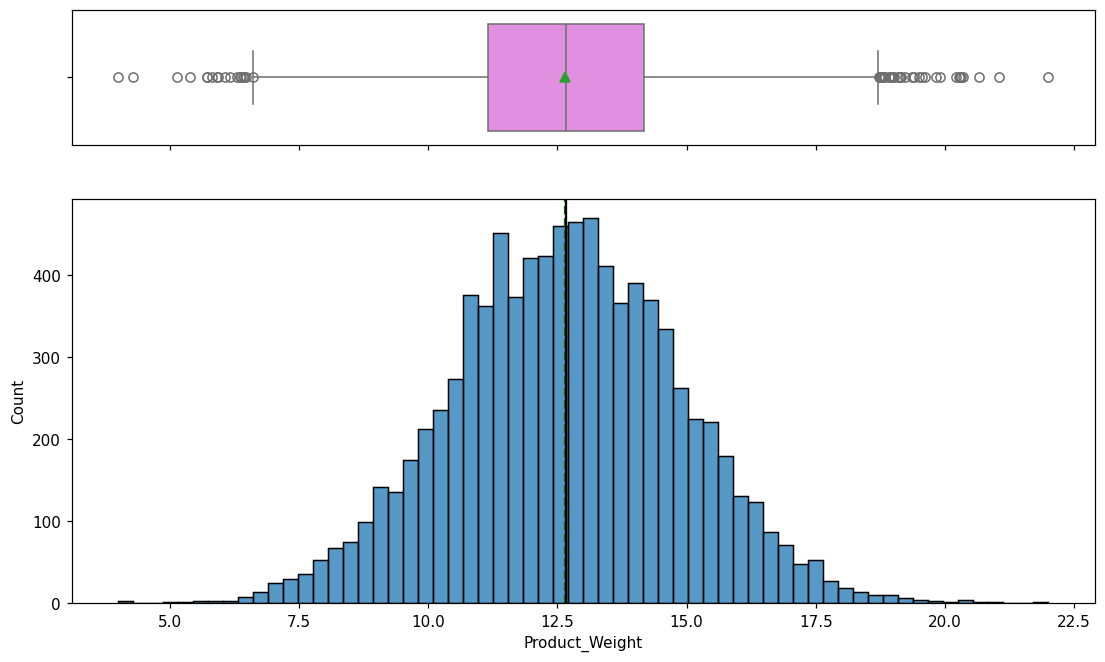

In [14]:
histogram_boxplot(data, "Product_Weight")

### **Product_Allocated_Area**

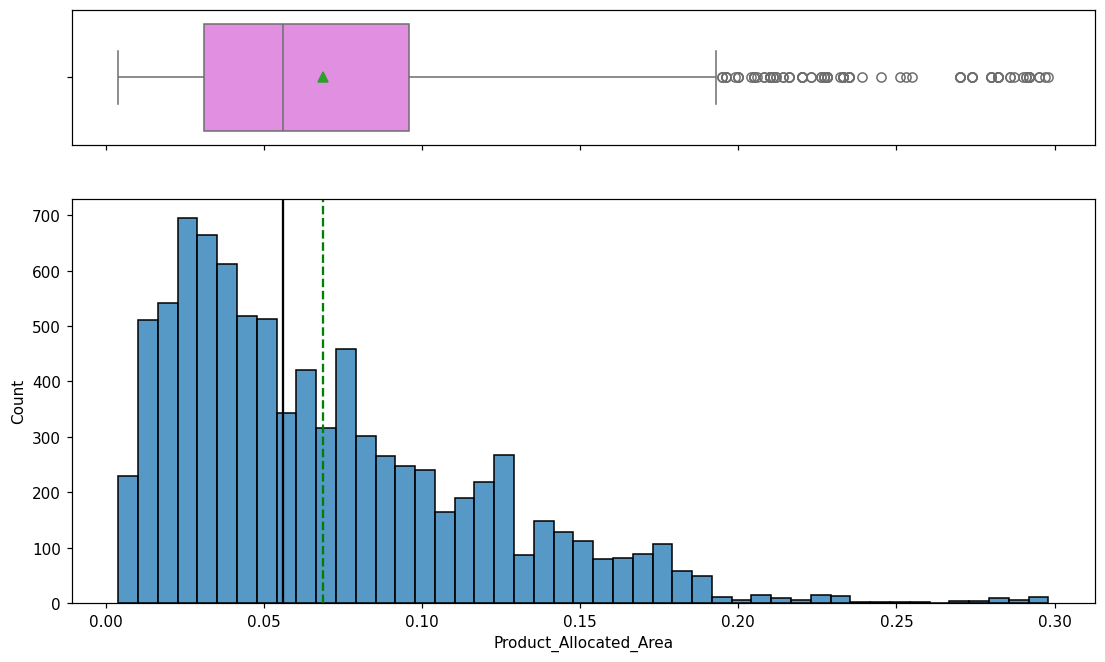

In [15]:
histogram_boxplot(data, "Product_Allocated_Area")


### **Product_MRP**

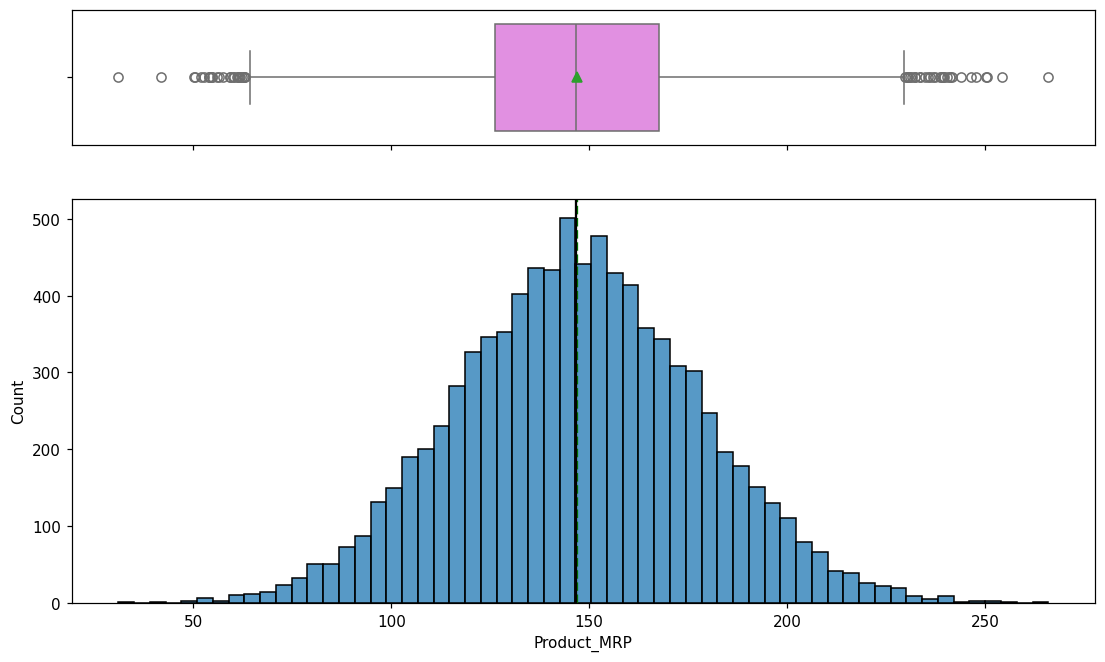

In [16]:
histogram_boxplot(data, "Product_MRP")


### **Product_Store_Sales_Total**

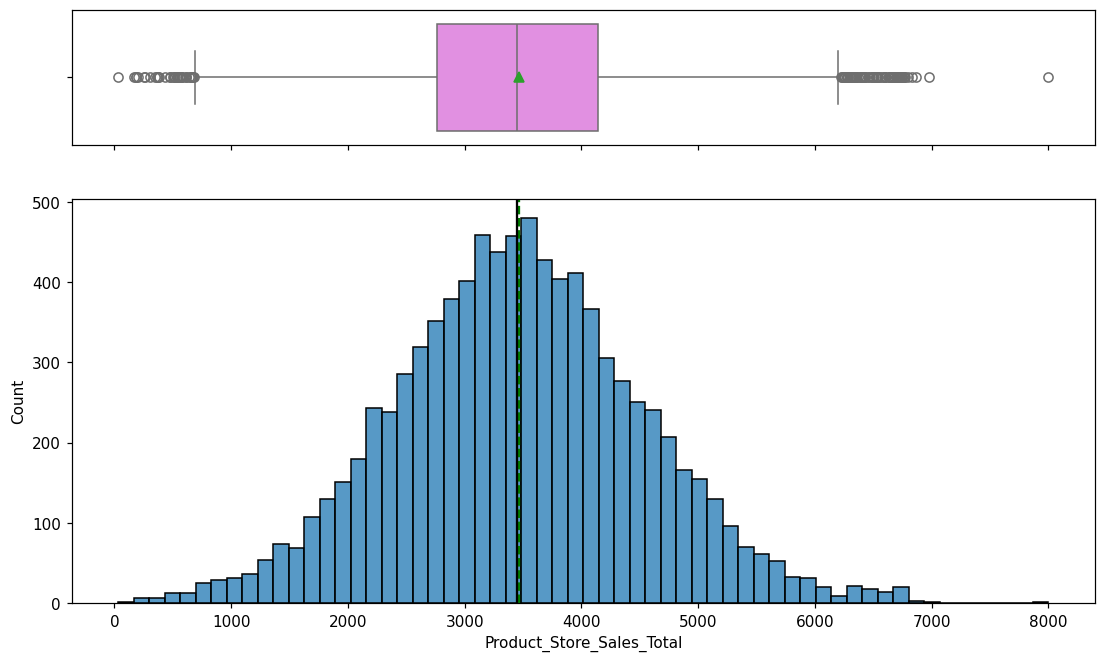

In [17]:
histogram_boxplot(data, "Product_Store_Sales_Total")


In [18]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### **Product_Sugar_Content**

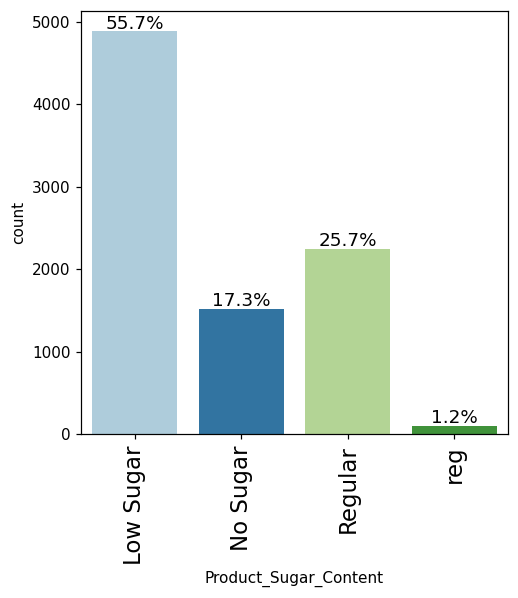

In [19]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

### **Product_Type**

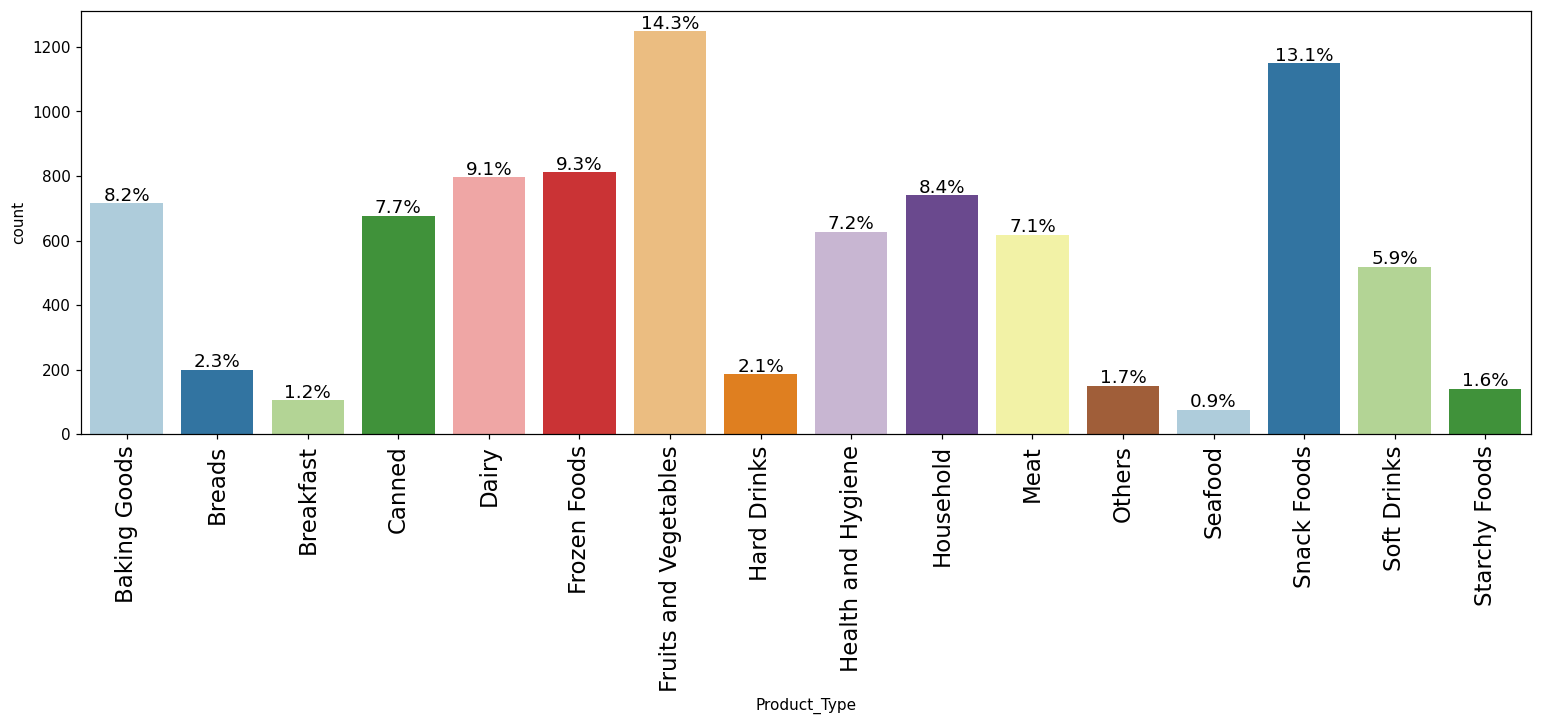

In [20]:
labeled_barplot(data, "Product_Type", perc=True)


### **Store_Id**

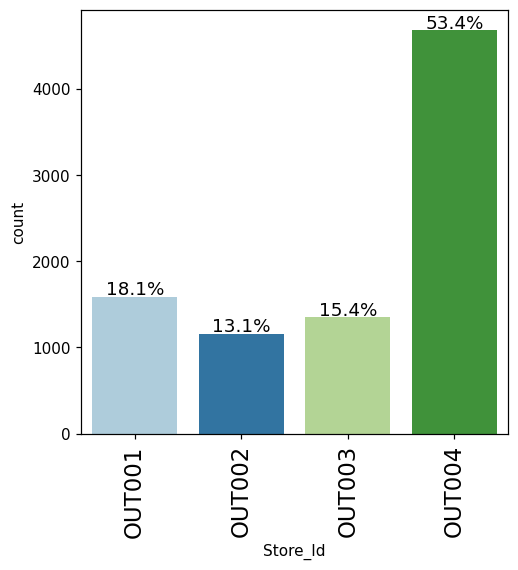

In [21]:
labeled_barplot(data, "Store_Id", perc=True)


### **Store_Size**

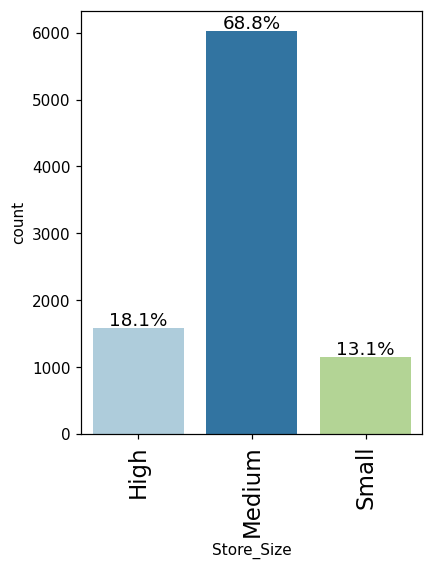

In [22]:
labeled_barplot(data, "Store_Size", perc=True)


### **Store_Location_City_Type**

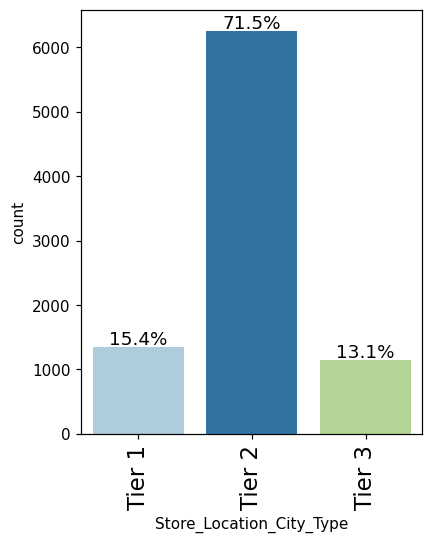

In [23]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)


### **Store_Type**

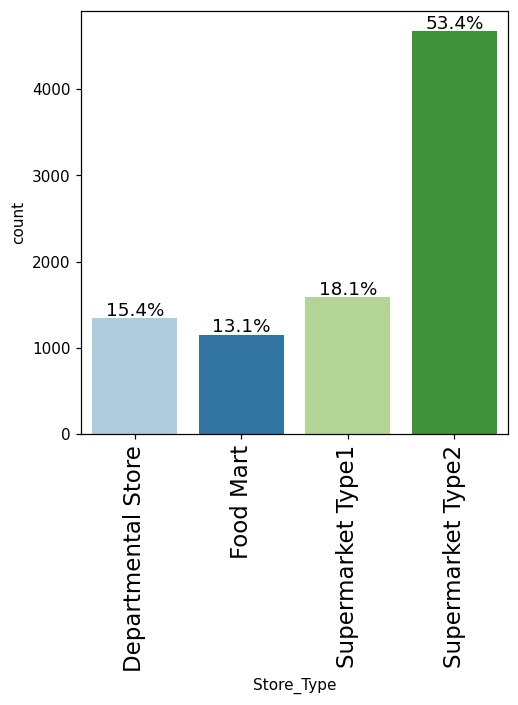

In [24]:
labeled_barplot(data, "Store_Type", perc=True)


## Bivariate Analysis

### **Correlation matrix**

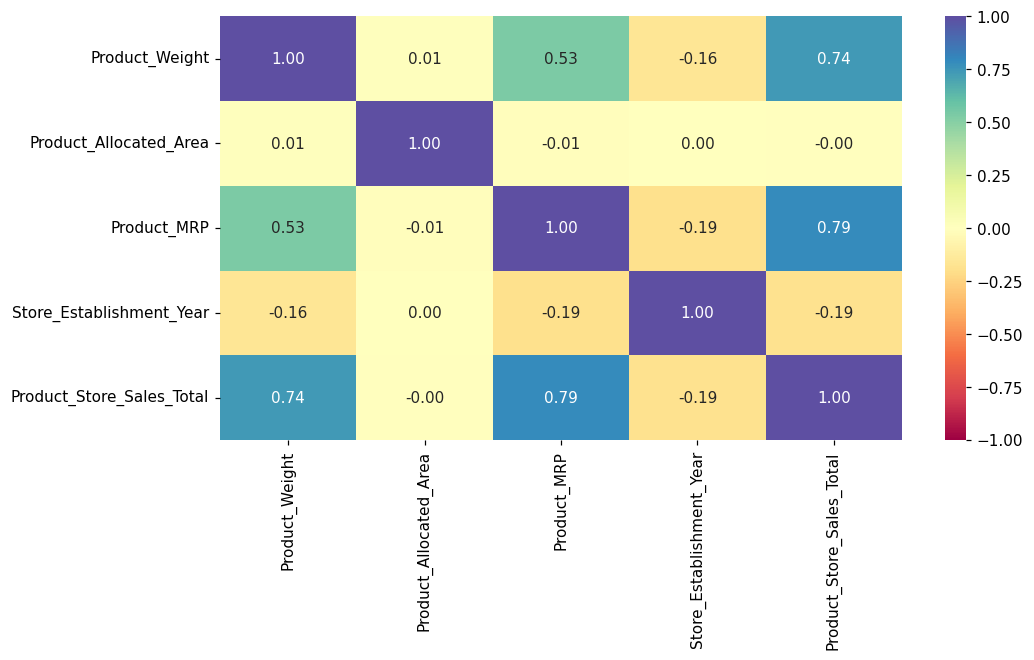

In [25]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns**

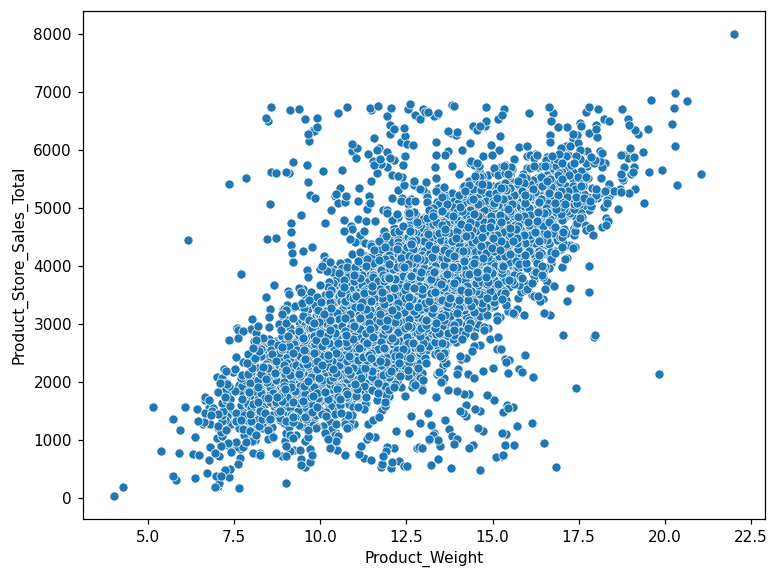

In [26]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)
plt.show()

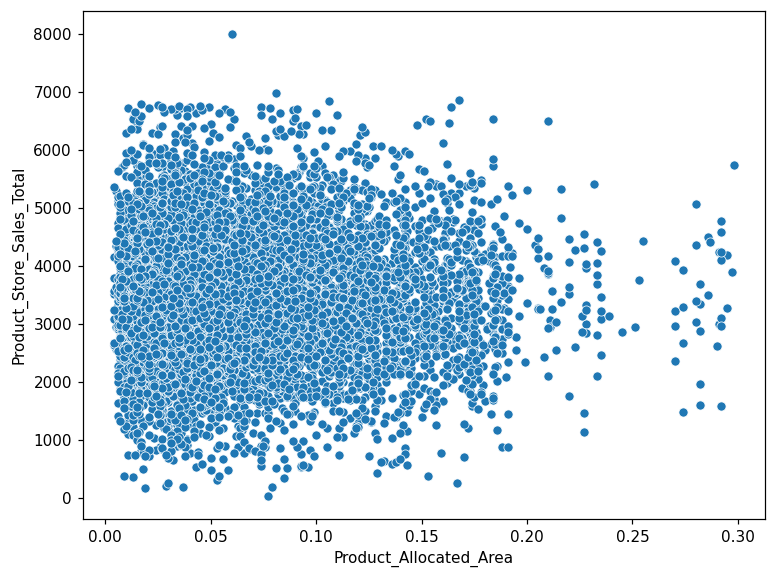

In [27]:
plt.figure(figsize=[8, 6])
sns.scatterplot(data=data, x='Product_Allocated_Area', y='Product_Store_Sales_Total')
plt.show()


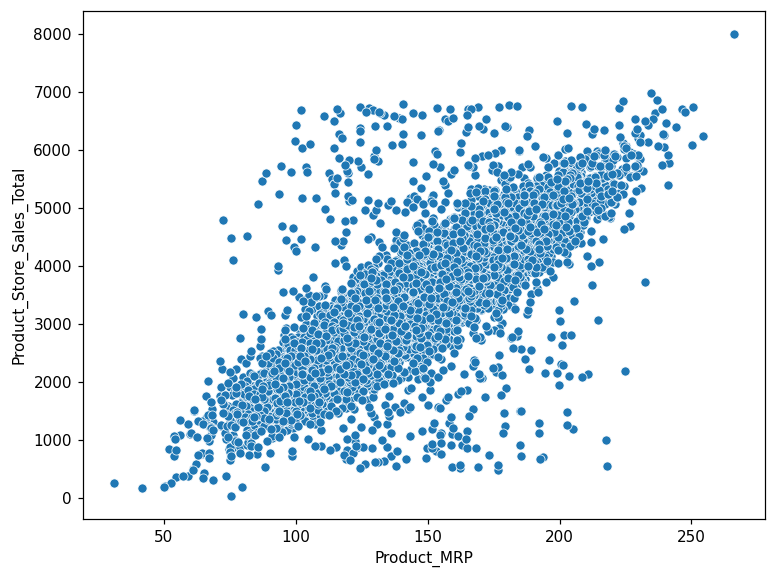

In [28]:
plt.figure(figsize=[8, 6])
sns.scatterplot(data=data, x='Product_MRP', y='Product_Store_Sales_Total')
plt.show()


### **Let us see from which product type the company is generating most of the revenue**

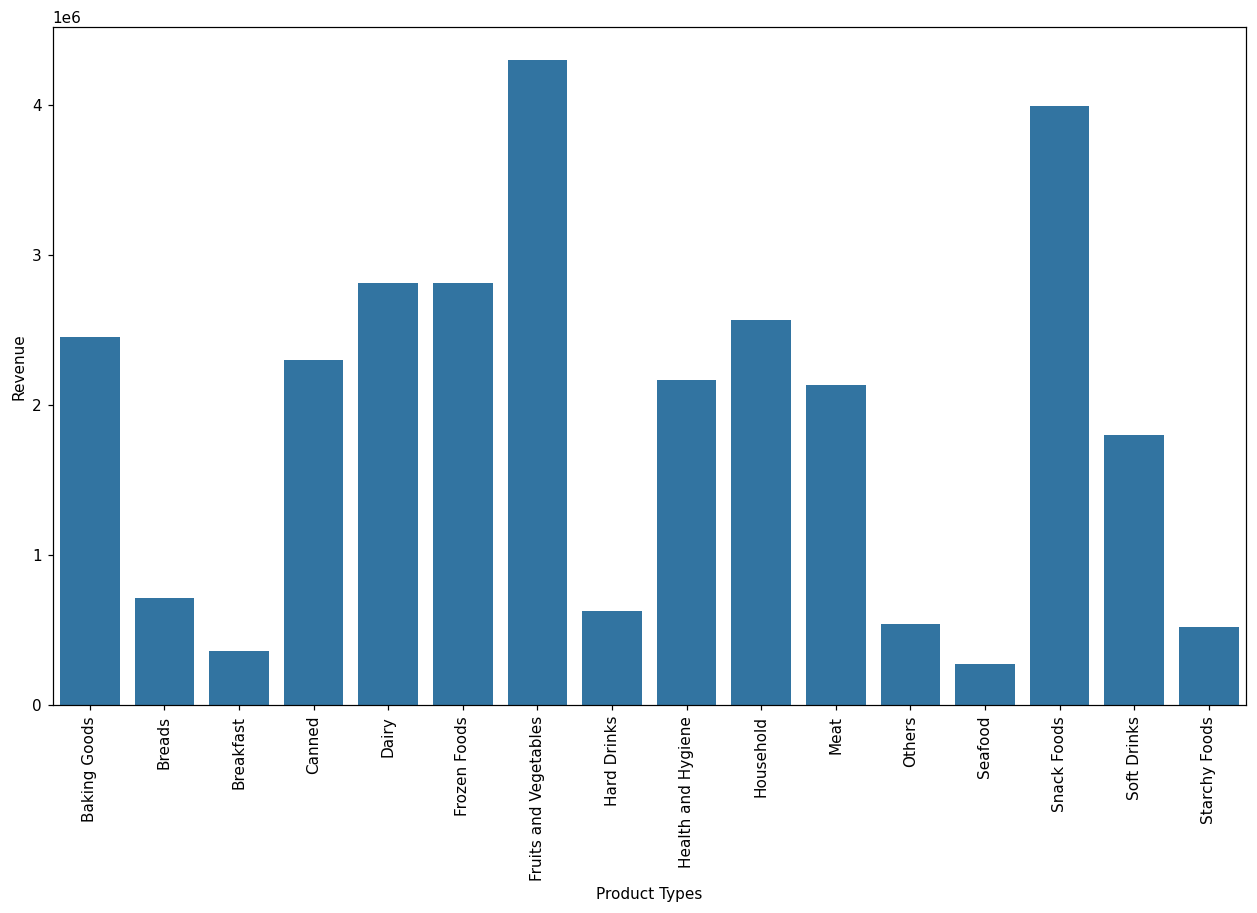

In [29]:
df_revenue1 = data.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

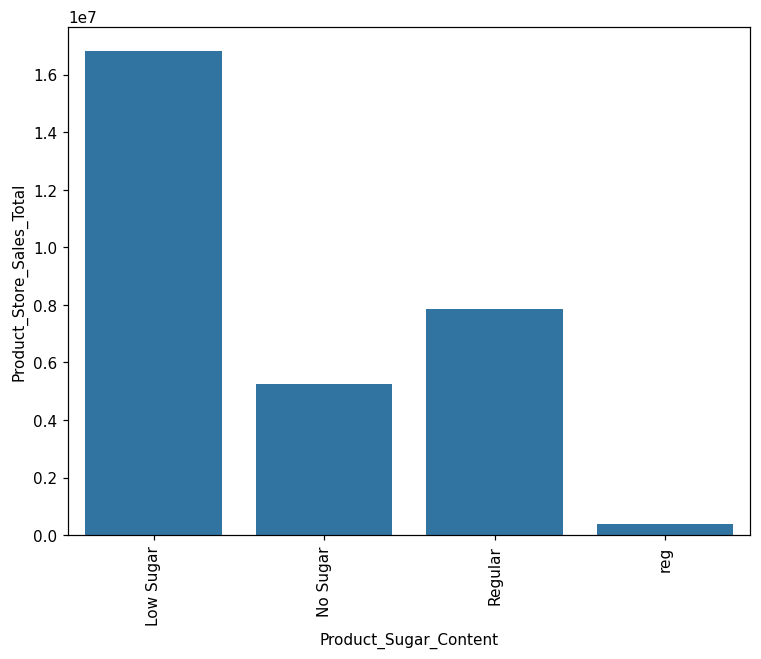

In [30]:
df_revenue2 = data.groupby('Product_Sugar_Content', as_index=False)['Product_Store_Sales_Total'].sum()
plt.figure(figsize=[8, 6])
sns.barplot(data=df_revenue2, x='Product_Sugar_Content', y='Product_Store_Sales_Total')
plt.xticks(rotation=90)
plt.show()


### **Let us see from which type of stores and locations the revenue generation is more**.

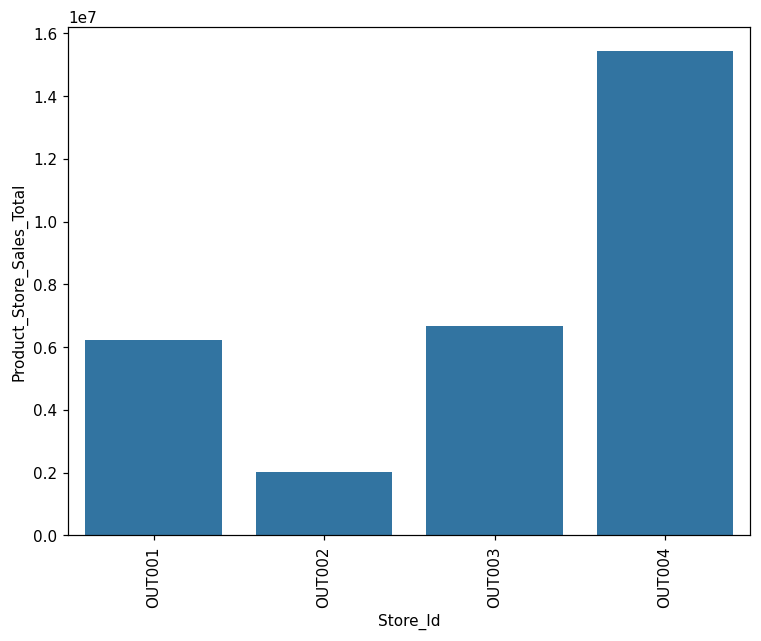

In [31]:
df_store_revenue = data.groupby('Store_Id', as_index=False)['Product_Store_Sales_Total'].sum()
plt.figure(figsize=[8, 6])
sns.barplot(data=df_store_revenue, x='Store_Id', y='Product_Store_Sales_Total')
plt.xticks(rotation=90)
plt.show()


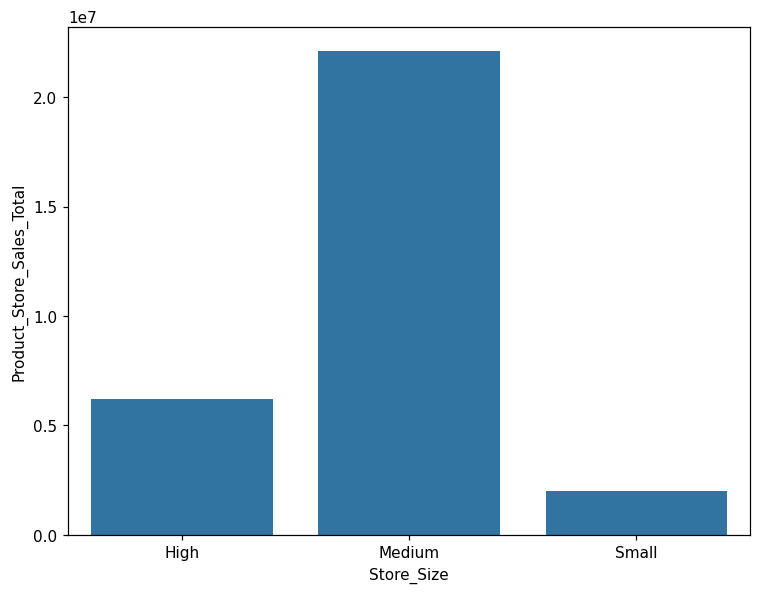

In [32]:
df_revenue3 = data.groupby('Store_Size', as_index=False)['Product_Store_Sales_Total'].sum()
plt.figure(figsize=[8, 6])
sns.barplot(data=df_revenue3, x='Store_Size', y='Product_Store_Sales_Total')
plt.show()


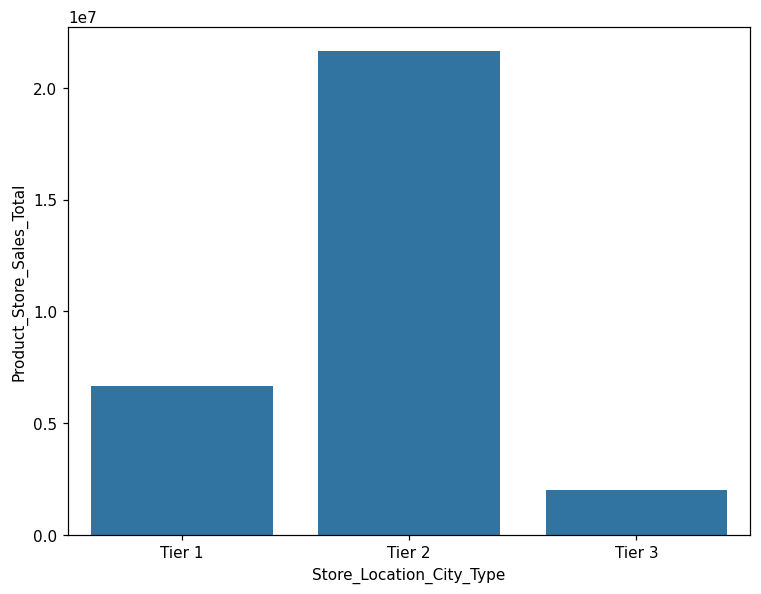

In [33]:
df_revenue4 = data.groupby('Store_Location_City_Type', as_index=False)['Product_Store_Sales_Total'].sum()
plt.figure(figsize=[8, 6])
sns.barplot(data=df_revenue4, x='Store_Location_City_Type', y='Product_Store_Sales_Total')
plt.show()


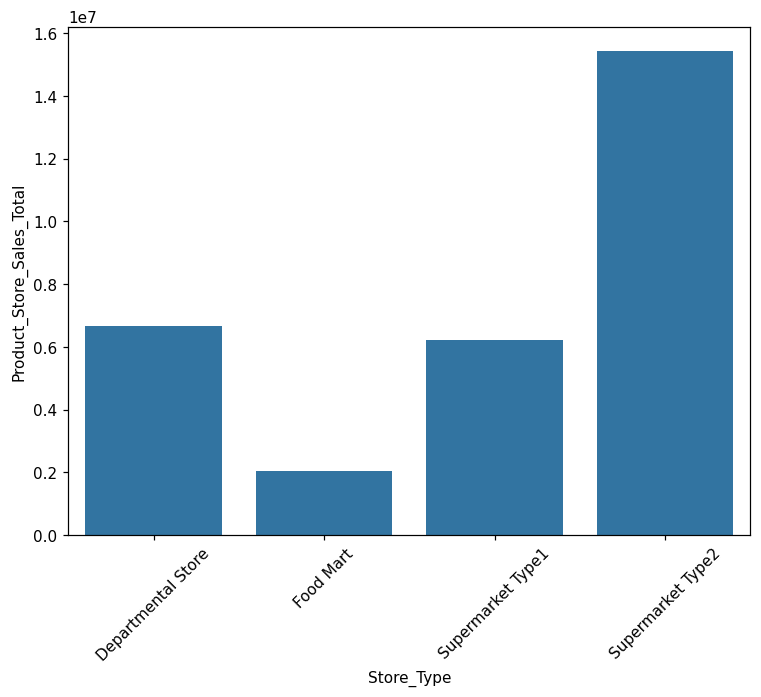

In [34]:
df_revenue5 = data.groupby('Store_Type', as_index=False)['Product_Store_Sales_Total'].sum()
plt.figure(figsize=[8, 6])
sns.barplot(data=df_revenue5, x='Store_Type', y='Product_Store_Sales_Total')
plt.xticks(rotation=45)
plt.show()


### **Let's check the distribution of our target variable i.e Product_Store_Sales_Total with the other categorical columns**

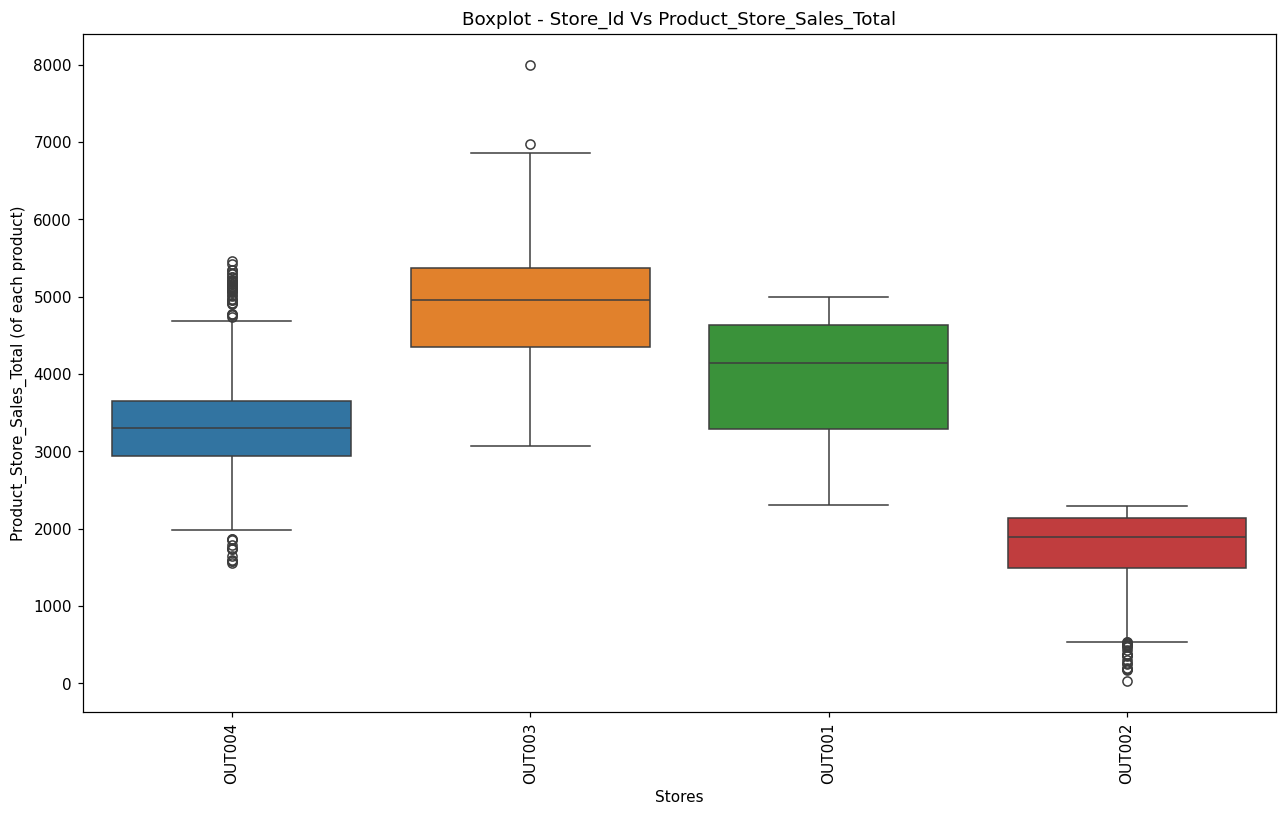

In [35]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

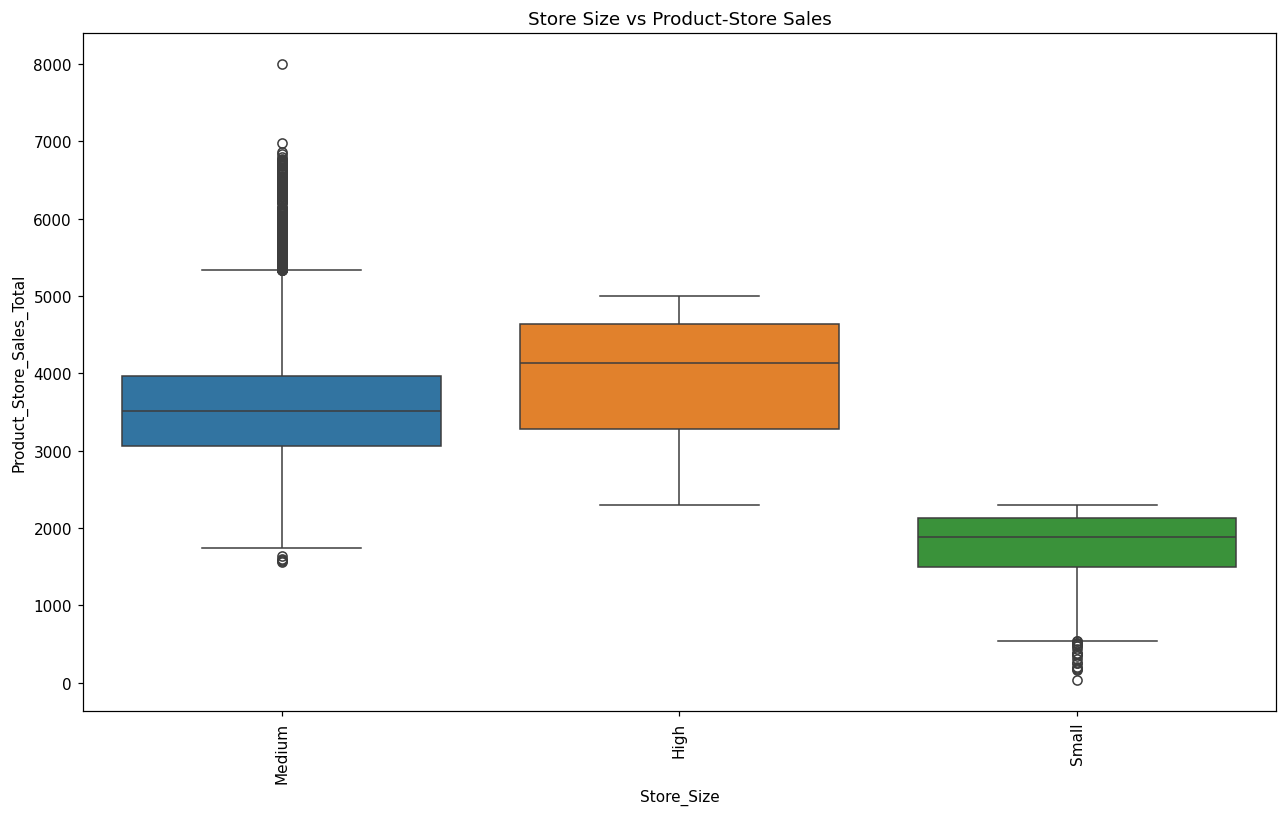

In [36]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x='Store_Size', y='Product_Store_Sales_Total', hue='Store_Size', legend=False)
plt.xticks(rotation=90)
plt.title('Store Size vs Product-Store Sales')
plt.show()


### **Let's now try to find out some relationship between the other columns**

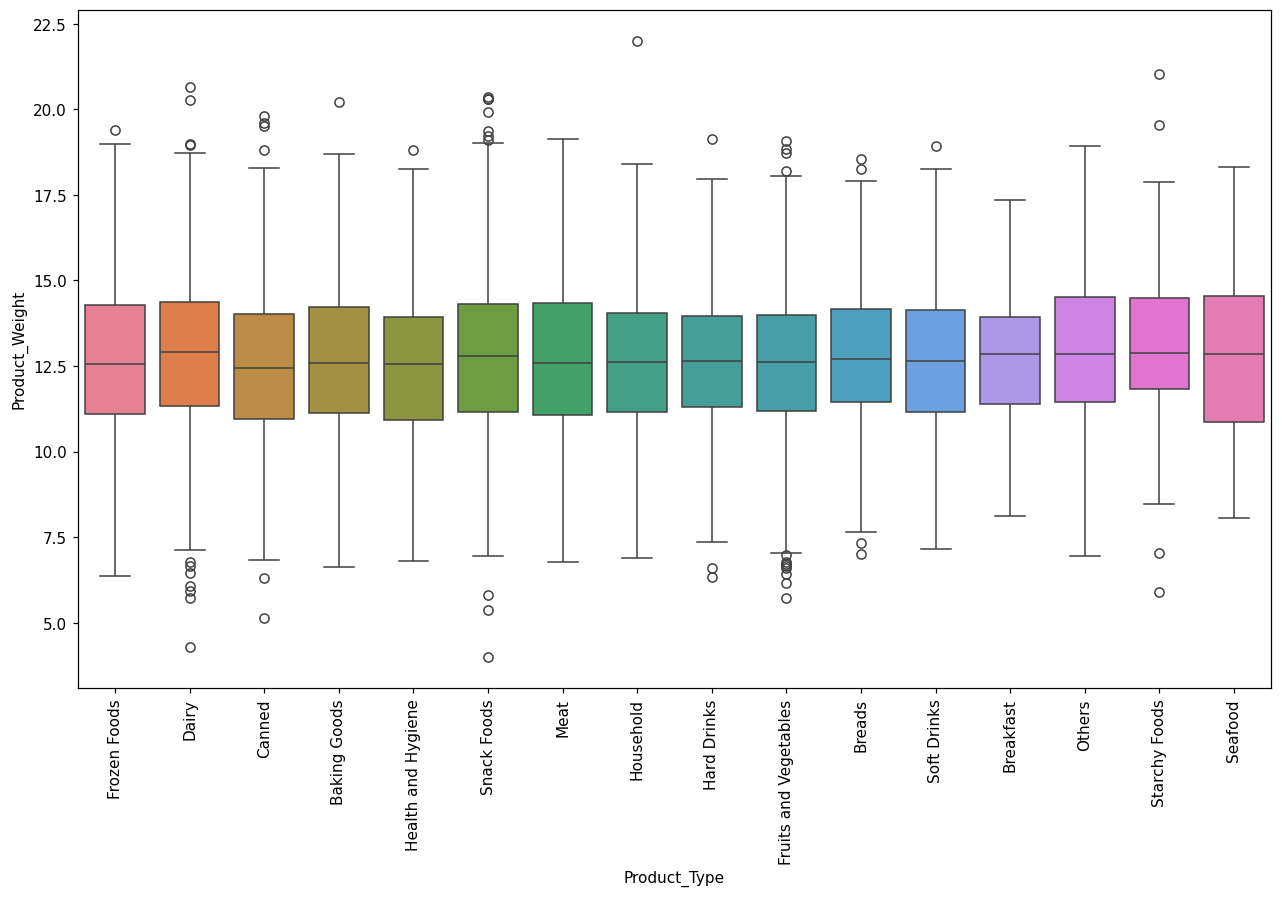

In [37]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x='Product_Type', y='Product_Weight', hue='Product_Type', legend=False)
plt.xticks(rotation=90)
plt.show()


### **Let's find out whether there is some relationship between the weight of the product and its sugar content**

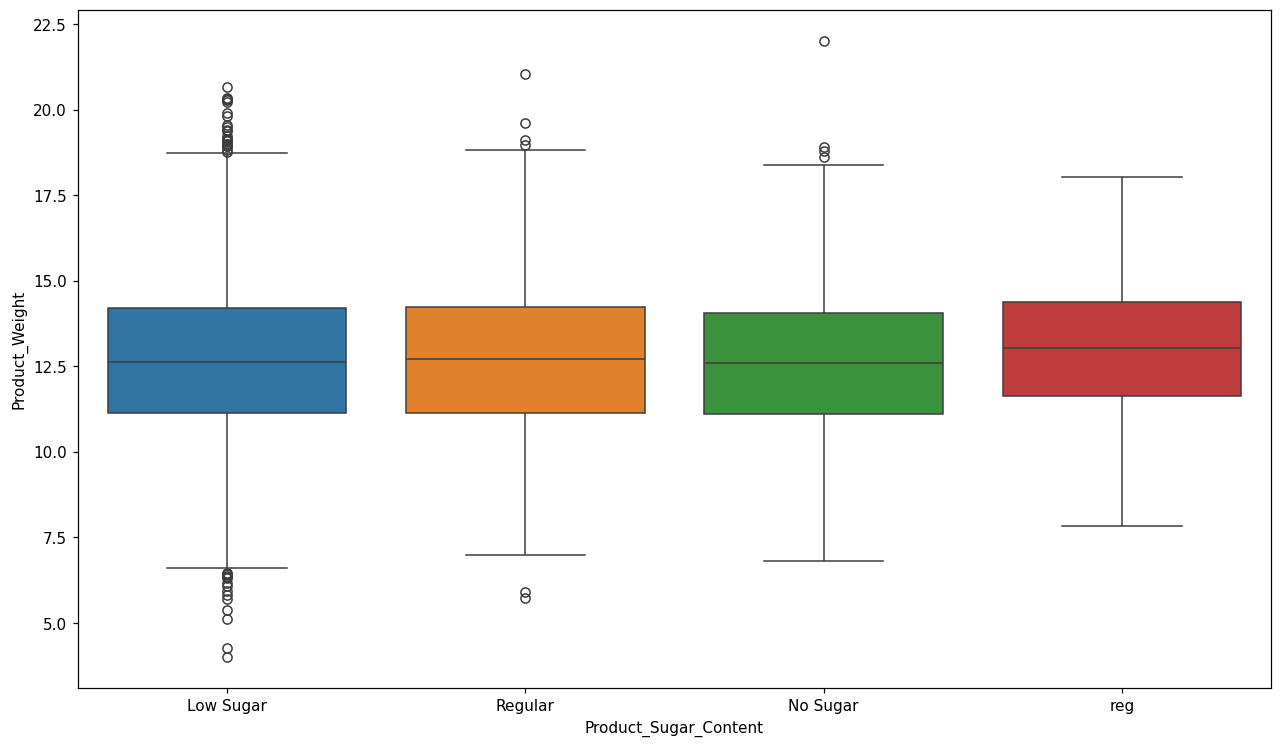

In [38]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x='Product_Sugar_Content', y='Product_Weight', hue='Product_Sugar_Content', legend=False)
plt.show()


### **Let's analyze the sugar content of different product types**

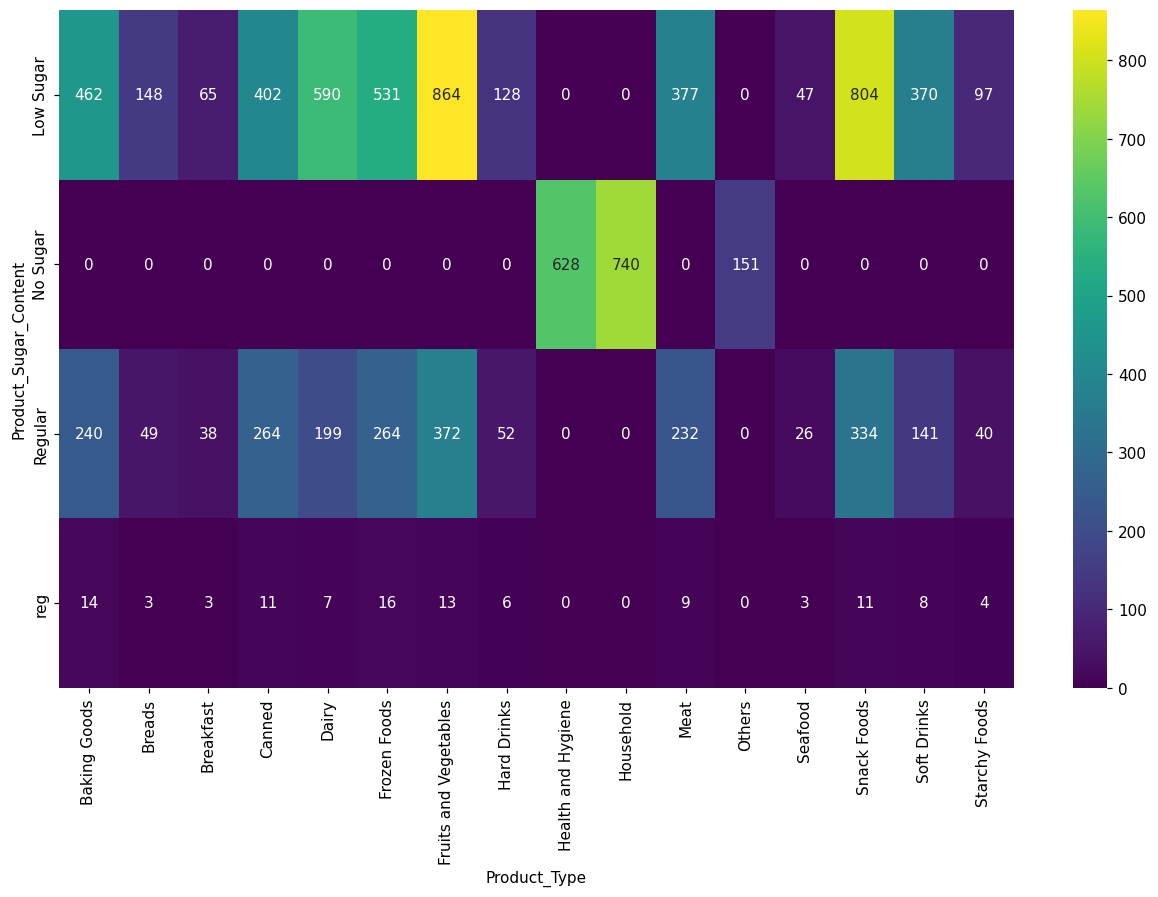

In [39]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Product_Sugar_Content")
plt.xlabel("Product_Type")
plt.show()

### **Let's find out how many items of each product type has been sold in each of the stores**

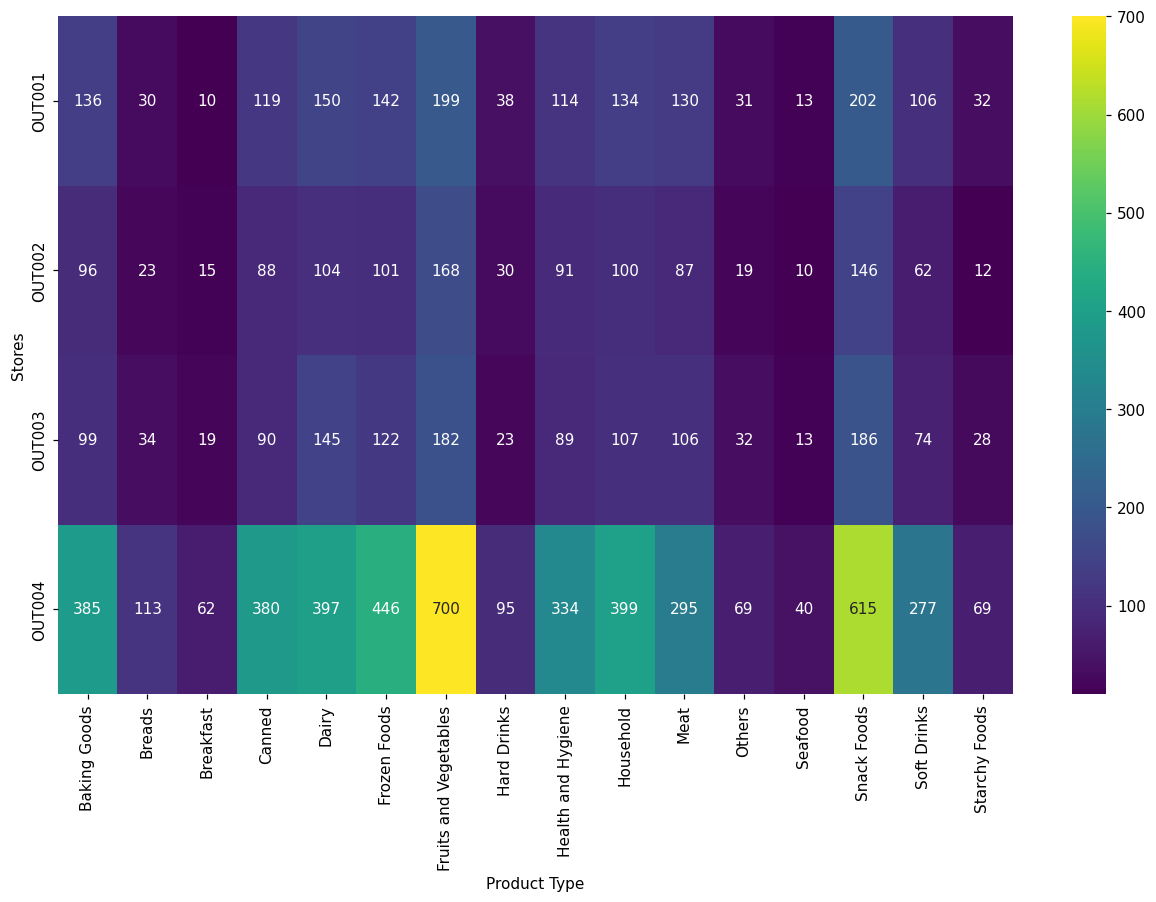

In [40]:
plt.figure(figsize=(14, 8))
sns.heatmap(pd.crosstab(data['Store_Id'], data['Product_Type']), annot=True, fmt='g', cmap='viridis')
plt.ylabel('Stores')
plt.xlabel('Product Type')
plt.show()


### **Different product types have different prices. Let's analyze the trend.**

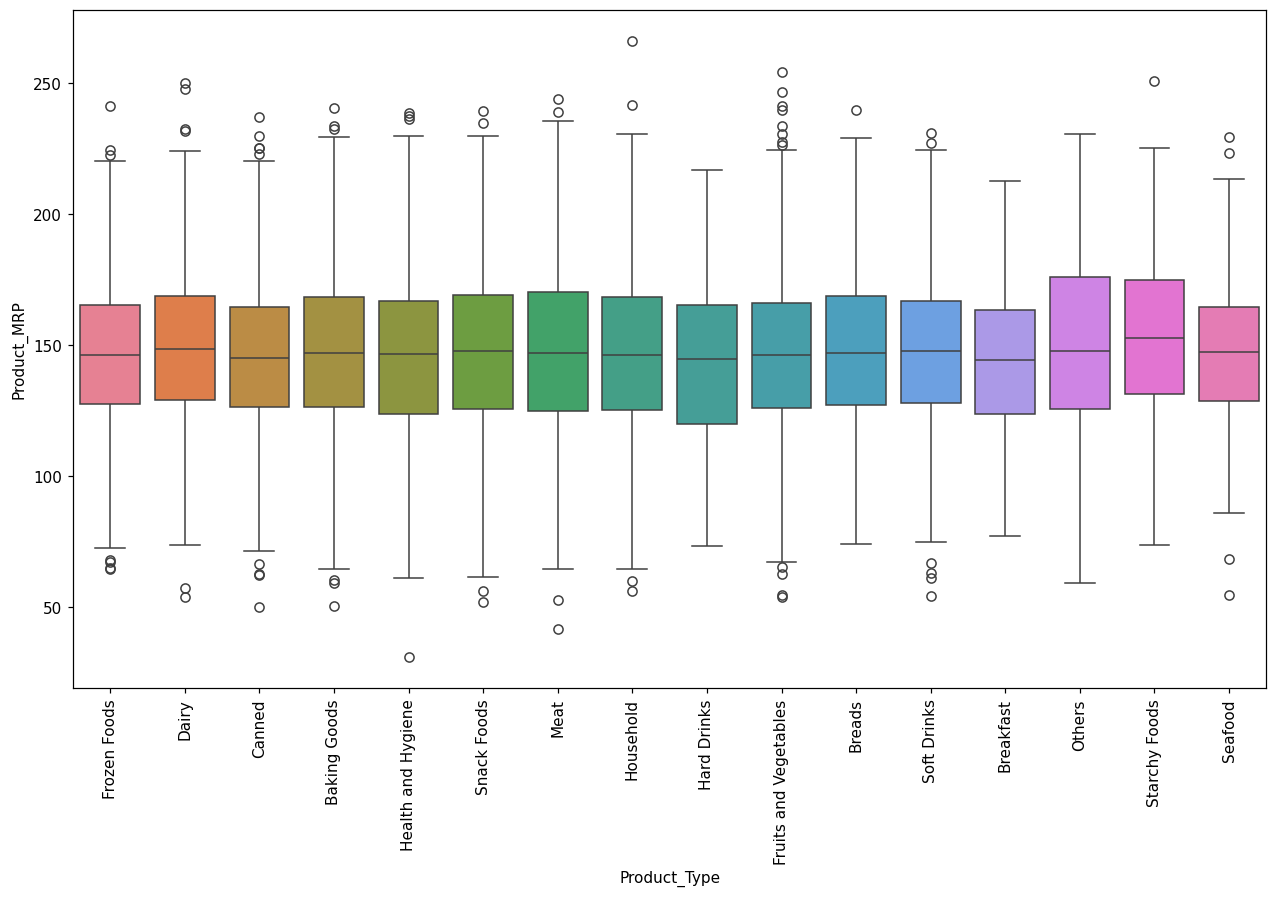

In [41]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x='Product_Type', y='Product_MRP', hue='Product_Type', legend=False)
plt.xticks(rotation=90)
plt.show()


### **Let's find out how the Product_MRP varies with the different stores**

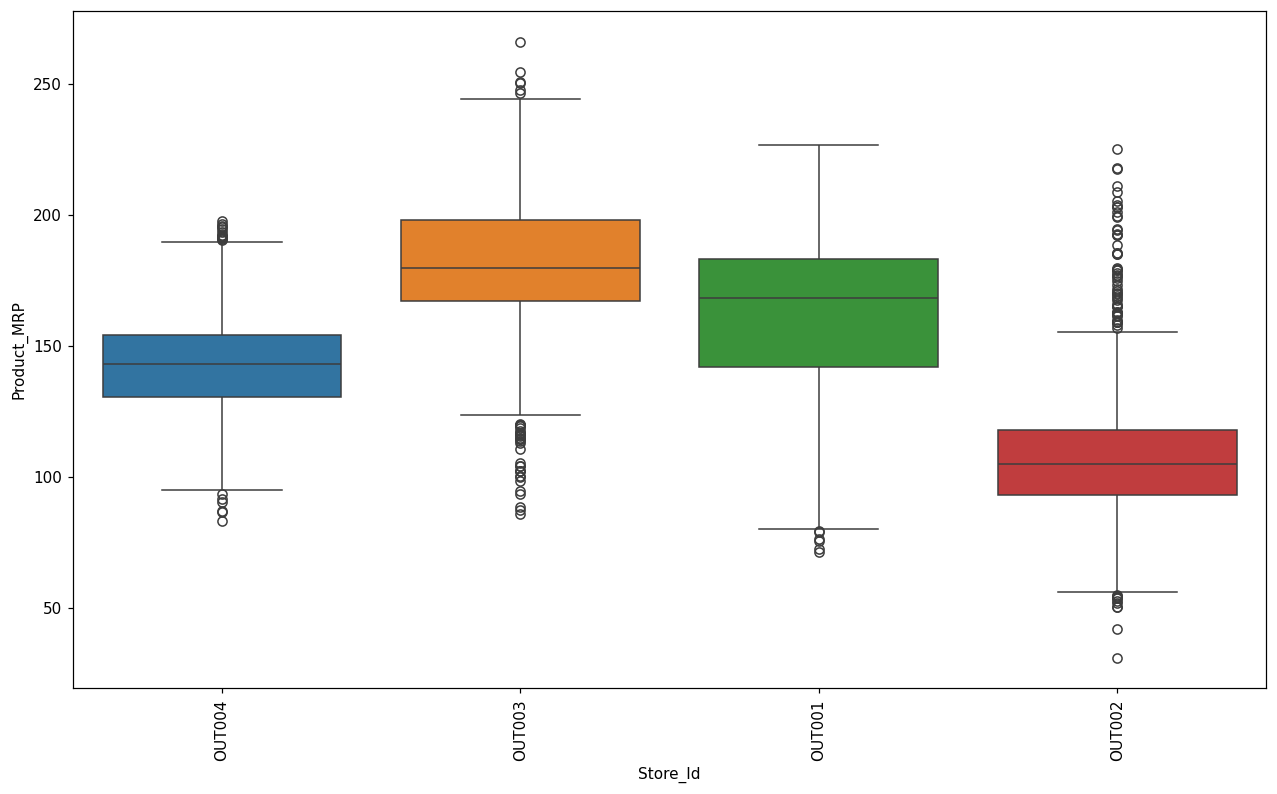

In [42]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x='Store_Id', y='Product_MRP', hue='Store_Id', legend=False)
plt.xticks(rotation=90)
plt.show()


### **Let's delve deeper and do a detailed analysis of each of the stores**.

#### OUT001

In [43]:
data.loc[data["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,FD5075,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,4,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT001 is a store of Supermarket Type 1 which is located in a Tier 2 city and has store size as high. It was established in 1987.
- OUT001 has sold products whose MRP range from 71 to 227.
- Snack Foods have been sold the highest number of times in OUT001.
- The revenue generated from each product at OUT001 ranges from 2300 to 5000.

In [44]:
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

**OUT001 has generated total revenue of 6223113 from the sales of goods.**

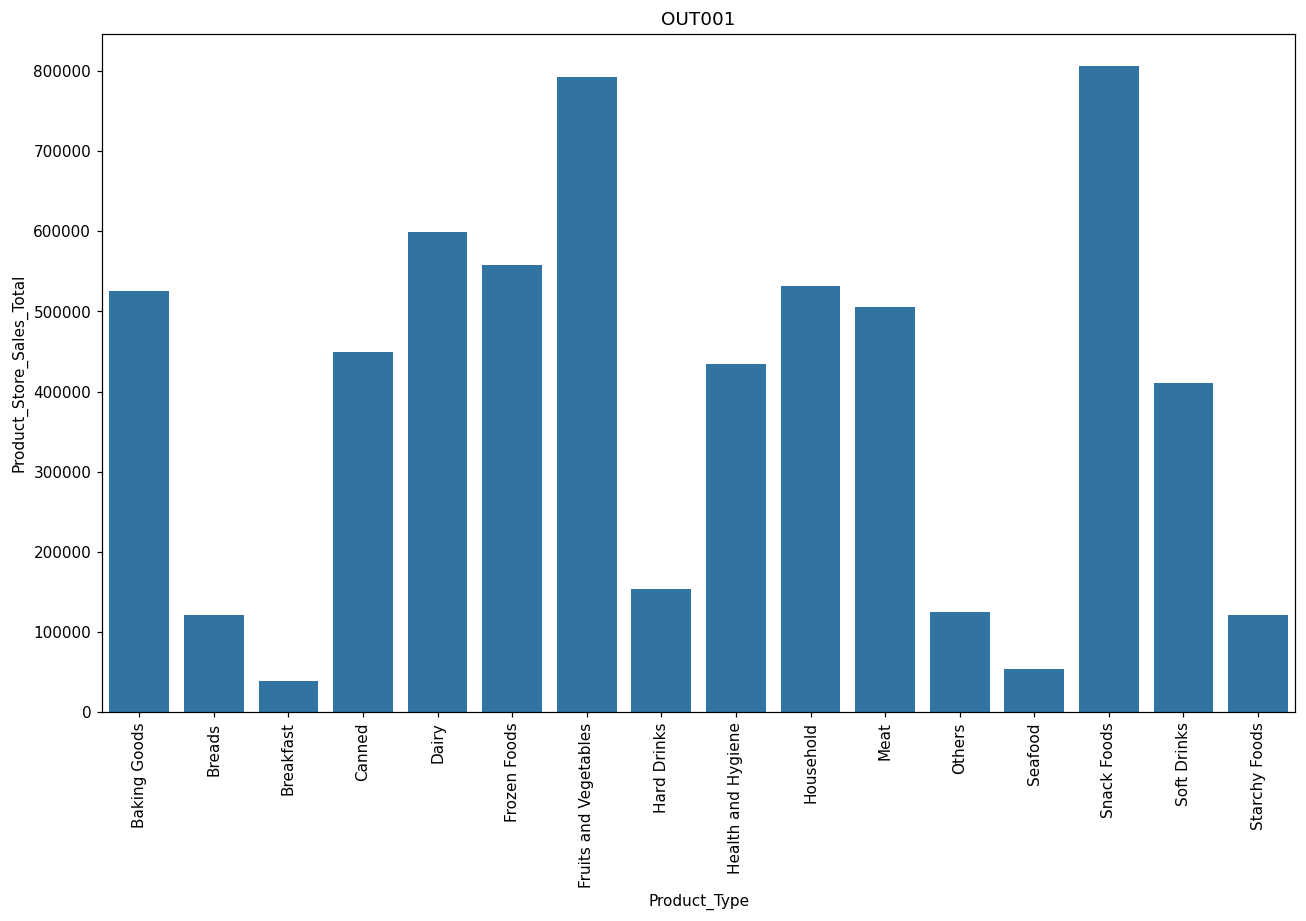

In [45]:
df_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total)
plt.show()

- OUT001 has generated the highest revenue from the sale of fruits and vegetables and snack foods. Both the categories have contributed around 800000 each.

#### OUT002

In [46]:
data.loc[data["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,NC1180,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,4,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT002 is a food mart which is located in a Tier 3 city and has store size as small. It was established in 1998.
- OUT002 has sold products whose MRP range from 31 to 225.
- Fruits and vegetables have been sold the highest number of times in OUT002.
- The revenue generated from each product at OUT002 ranges from 33 to 2300.

In [47]:
data.loc[data["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

np.float64(2030909.72)

**OUT002 has generated total revenue of 2030910 from the sales of goods.**

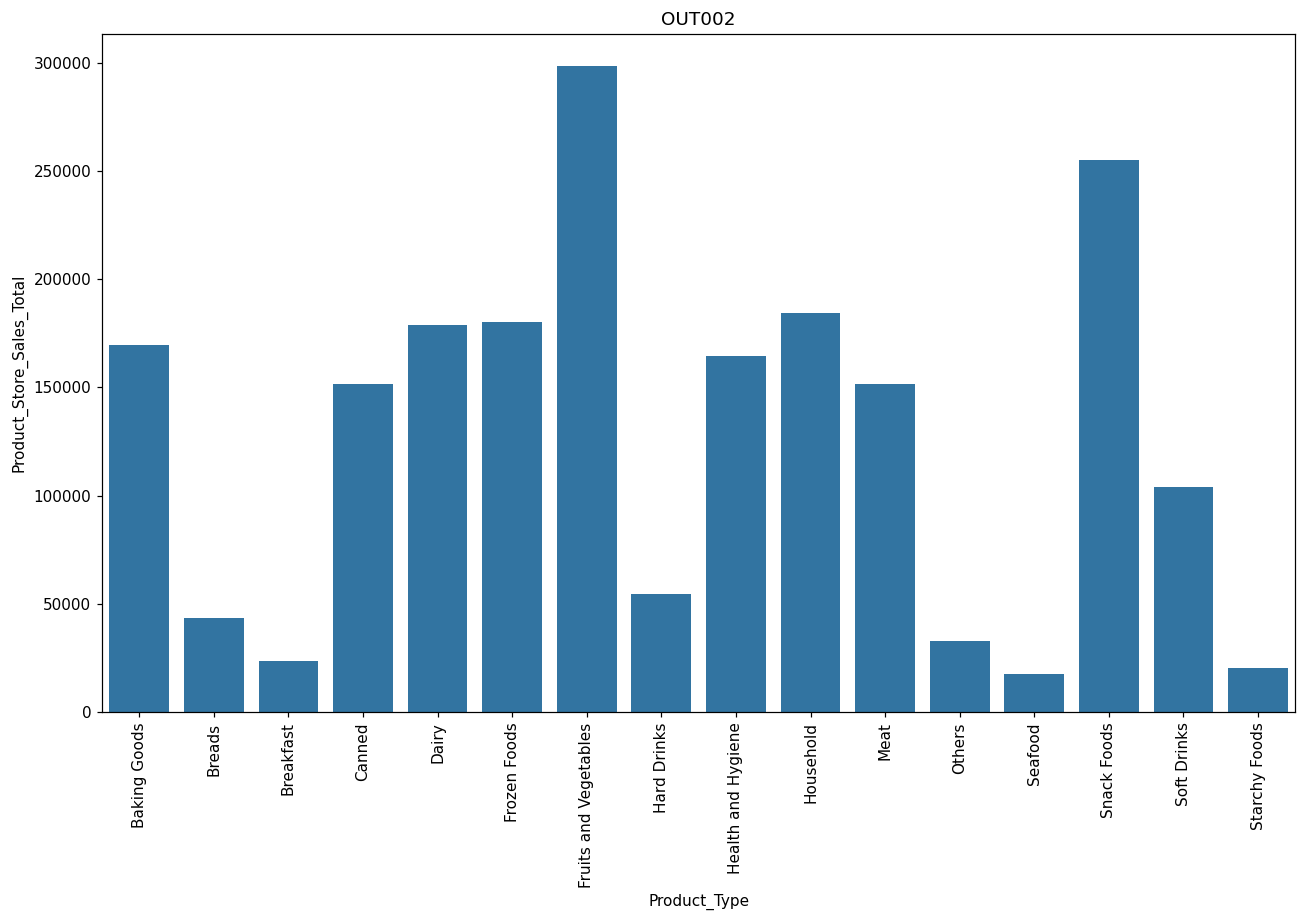

In [48]:
df_OUT002 = (
    data.loc[data["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=df_OUT002.Product_Type, y=df_OUT002.Product_Store_Sales_Total)
plt.show()

- OUT002 has generated the highest revenue from the sale of fruits and vegetables (~ 300000) followed by snack foods (~ 250000).

#### OUT003

In [49]:
data.loc[data["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,FD7839,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,4,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT003 is a Departmental store which is located in a Tier 1 city and has store size as medium. It was established in 1999.
- OUT003 has sold products whose MRP range from 86 to 266.
- Snack Foods have been sold the highest number of times in OUT003.
- The revenue generated from each product at OUT003 ranges from 3070 to 8000.

In [50]:
data.loc[data["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

np.float64(6673457.57)

**OUT003 has generated total revenue of 6673458 from the sales of goods.**

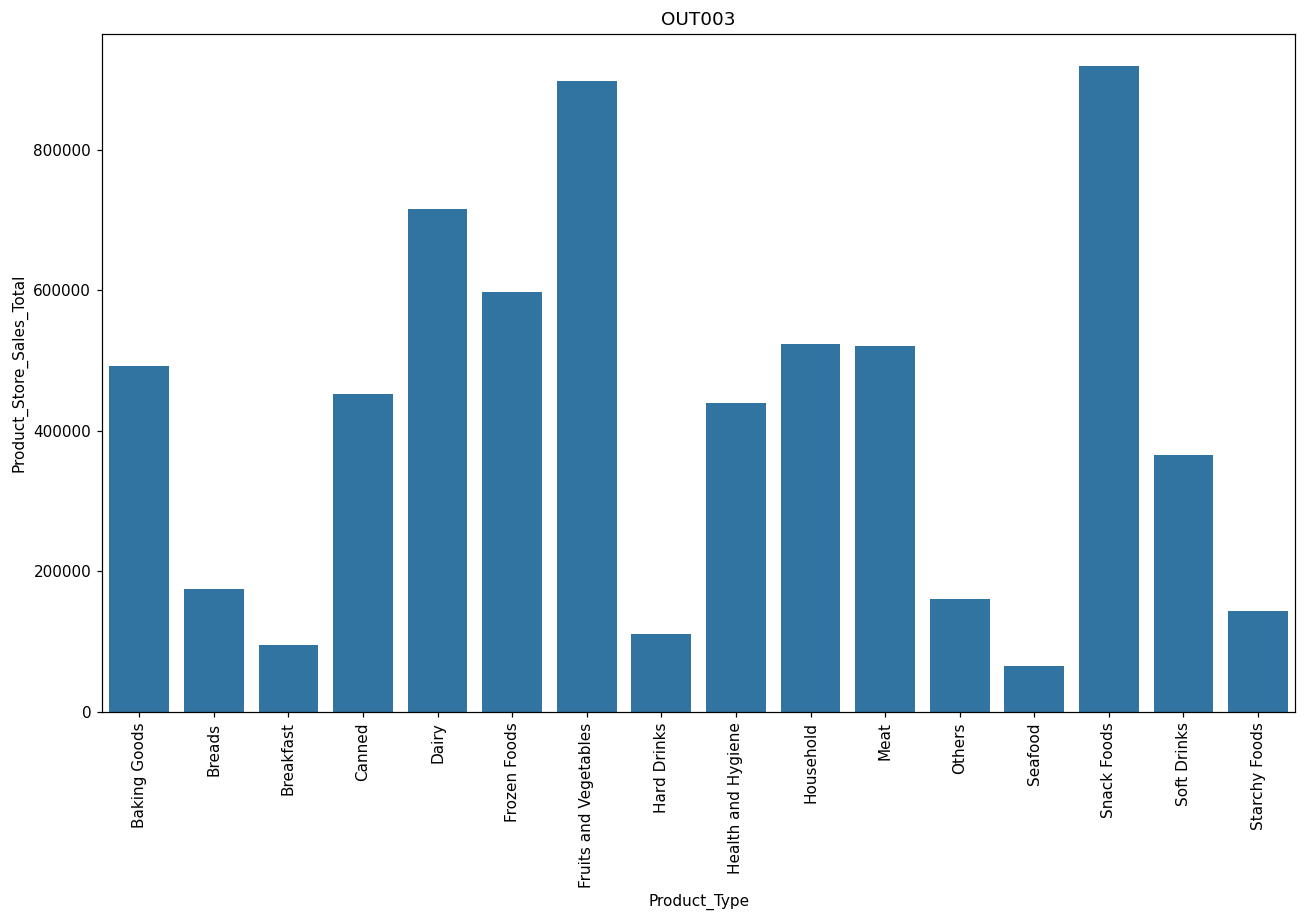

In [51]:
df_OUT003 = (
    data.loc[data["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=df_OUT003.Product_Type, y=df_OUT003.Product_Store_Sales_Total)
plt.show()

- OUT003 has generated the highest revenue from the sale of snack foods followed by fruits and vegetables, both the categories contributing around 800000 each.

#### OUT004

In [52]:
data.loc[data["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,4,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- OUT004 is a store of Supermarket Type2 which is located in a Tier 2 city and has store size as medium. It was established in 2009.
- OUT004 has sold products whose MRP range from 83 to 198.
- Fruits and vegetables have been sold the highest number of times in OUT004.
- The revenue generated from each product at OUT004 ranges from 1561 to 5463.

In [53]:
data.loc[data["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

np.float64(15427583.43)

**OUT004 has generated total revenue of 15427583 from the sales of goods which is highest among all the 4 stores.**

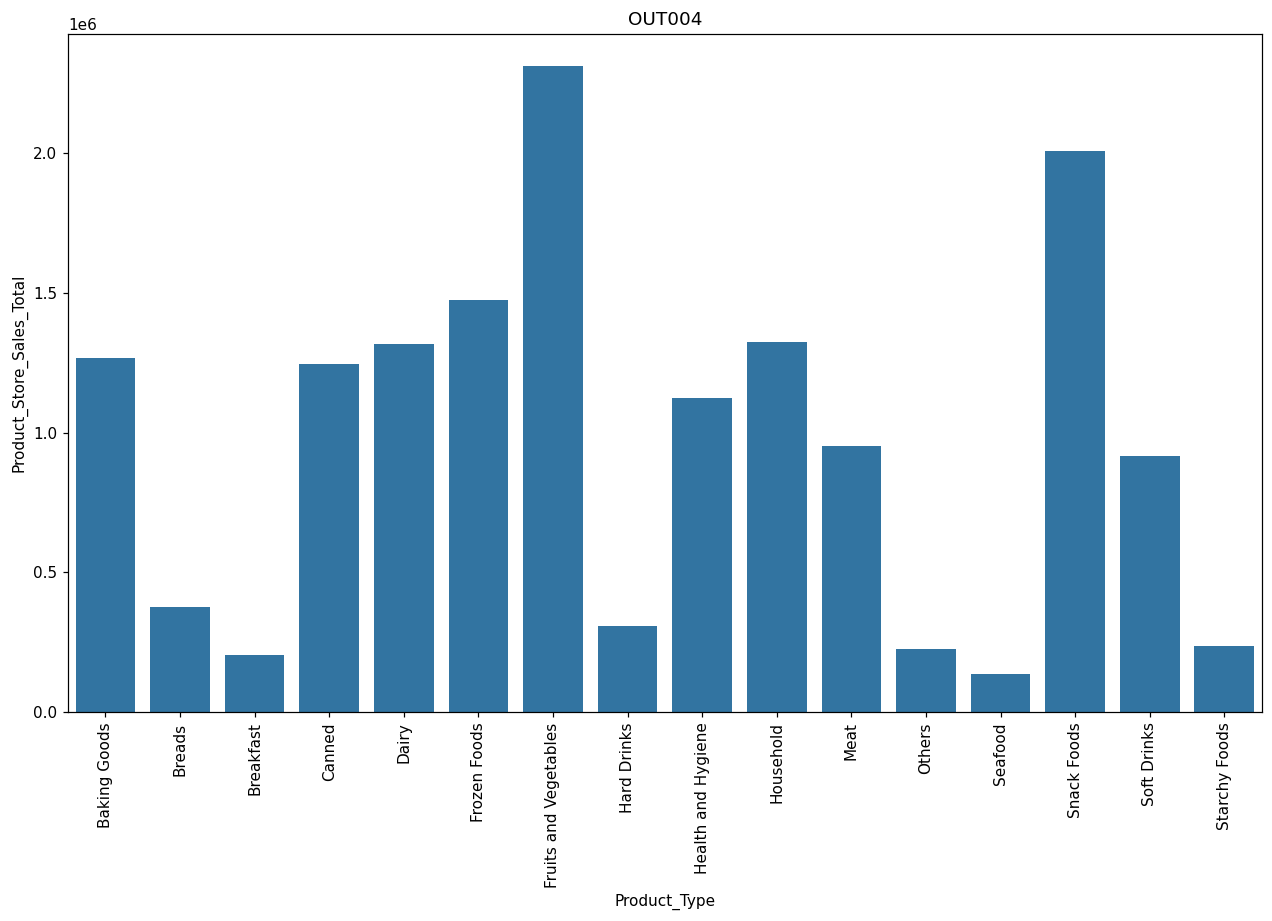

In [54]:
df_OUT004 = (
    data.loc[data["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=df_OUT004.Product_Type, y=df_OUT004.Product_Store_Sales_Total)
plt.show()

- OUT004 has generated the highest revenue from the sale of fruits and vegetables (~ 2500000) followed by snack foods (~ 2000000).

**Let's find out the revenue generated by the stores from each of the product types**.

In [55]:
df1 = data.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


- In all the product types, the revenue generated by OUT004 has been the highest which seems quite logical since around 53% of the total products were brought from this store.
- In all the product categories, the revenue generated by OUT002 has been the lowest which seems quite obvious since it is small store in a Tier 3 city.

**Let's find out the revenue generated by the stores from products having different levels of sugar content**.

In [56]:
df2 = data.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1749444.51
9,Regular,OUT002,472112.50


- The trend is the same as that which was present in the revenue analysis of stores for product types.

# **Data Preprocessing**

## **Replacing the values in the Product_Sugar_Content column**

We can observe that in the Product_Sugar_Content column, there are 3 types - Low Sugar, Regular and reg.

It seems quite obvious that Regular and reg are referring to the same category. So let's replace reg with Regular.

In [57]:
# Replacing reg with Regular
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [58]:
data.Product_Sugar_Content.value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

## **Exploring Patterns in Product_IDs**

We can see that the Product_Id column has two characters followed by a number.

Let's delve deeper and see whether they are having any relationship with the other columns or not

In [59]:
## extracting the first two characters from the Product_Id column and storing it in another column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [60]:
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [61]:
data.loc[data.Product_Id_char == "FD", "Product_Type"].unique()

array(['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods',
       'Meat', 'Fruits and Vegetables', 'Breads', 'Breakfast',
       'Starchy Foods', 'Seafood'], dtype=object)

In [62]:
data.loc[data.Product_Id_char == 'DR', 'Product_Type'].unique()


array(['Hard Drinks', 'Soft Drinks'], dtype=object)

In [63]:
data.loc[data.Product_Id_char == 'NC', 'Product_Type'].unique()


array(['Health and Hygiene', 'Household', 'Others'], dtype=object)

## **Store's Age**

A store which has been in the business for a long duration is more trustworthy than the newly established ones.

On the other hand, older stores may sometimes lack infrastructure if proper attention is not given. So let us calculate the current age of the store and incorporate that in our model.

In [64]:
# Outlet Age
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year

## **Grouping Product Types into Perishables and Non-Perishables.**

We have 16 different product types in our dataset.

So let us make two broad categories, perishables and non perishables, in order to reduce the number of product types

In [65]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [66]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [67]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [68]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


## **Outlier Check**

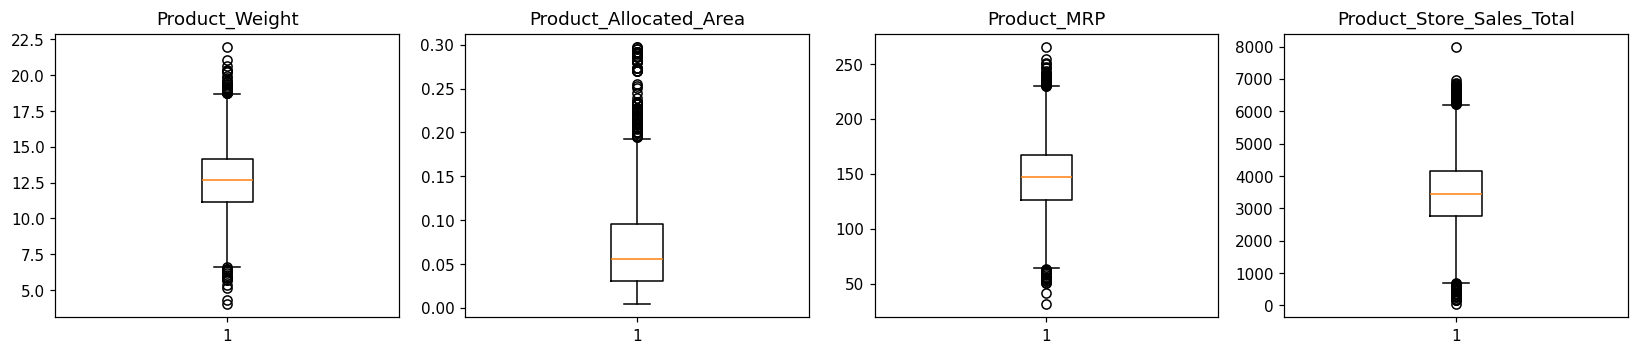

In [69]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

## **Data Preparation for Modeling**

- We aim to forecast the Product_Store_Sales_Total.

- Before building the model, we'll drop unnecessary columns and encode the categorical features.

- We'll then split the data into training and testing sets to evaluate the model's performance on unseen data.

In [70]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


Let's remove the columns that are not required.

In [71]:
data = data.drop(['Product_Id', 'Product_Type', 'Store_Id', 'Store_Establishment_Year'], axis=1)


In [72]:
data.shape

(8763, 11)

In [73]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [74]:
X = data.drop('Product_Store_Sales_Total', axis=1)
y = data['Product_Store_Sales_Total']


In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, shuffle=True
)


In [76]:
X_train.shape, X_test.shape

((6134, 10), (2629, 10))

### **Data Pre-processing Pipeline**

In [77]:
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
print('Categorical features:', categorical_features)
print('Numeric features:', numeric_features)


Categorical features: ['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char', 'Product_Type_Category']
Numeric features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']


In [78]:
preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), categorical_features),
    remainder='passthrough'
)


# **Model Building**

<h2><b>Note: As per the rubric, you are required to build two ML models for this project. We have provided the code required for model building for six different ML models, each under a separate markdown section.  You may choose any two models from the ones provided below, uncomment the corresponding code for the model, and then run the code to build the model, and check its performance.</b></h2>

## Define functions for Model Evaluation

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and `r_2 score` to optimize the model.
- R-square - `Coefficient of determination` is used to evaluate the performance of a regression model. It is the amount of the variation in the output dependent attribute which is predictable from the input independent variables.
- Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

In [79]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

## Decision Tree Model

In [80]:
rf_estimator = make_pipeline(
    preprocessor,
    RandomForestRegressor(n_estimators=100, random_state=1, n_jobs=-1)
)
rf_estimator.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

### Checking model performance on training set

In [81]:
rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
rf_estimator_model_train_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,104.566026,39.946068,0.990337,0.990321,0.014121


### Checking model performance on test set

In [82]:
rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)
rf_estimator_model_test_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,295.940703,112.705907,0.923467,0.923174,0.050206


## Bagging Regressor

In [83]:
# Uncomment the below snippet of code if baggingregressor is to be used

#bagging_regressor = BaggingRegressor(random_state=1)
#bagging_regressor = make_pipeline(preprocessor,bagging_regressor)
#bagging_regressor.fit(X_train, y_train)


### Checking model performance on training set

In [84]:
# Uncomment the below snippet of code if baggingregressor is to be used

#bagging_regressor_model_train_perf = model_performance_regression(bagging_regressor, X_train, y_train)
#bagging_regressor_model_train_perf


### Checking model performance on test set

In [85]:
# Uncomment the below snippet of code if baggingregressor is to be used

#bagging_regressor_model_test_perf = model_performance_regression(bagging_regressor, X_test, y_test)
#bagging_regressor_model_test_perf


## Random Forest Model

In [86]:
# Uncomment the below snippet of code if random forest regressor is to be used

#rf_estimator = RandomForestRegressor(random_state=1)
#rf_estimator = make_pipeline(preprocessor,rf_estimator)
#rf_estimator.fit(X_train, y_train)


### Checking model performance on training set

In [87]:
# Uncomment the below snippet of code if random forest regressor is to be used

#rf_estimator_model_train_perf = model_performance_regression(rf_estimator, X_train, y_train)
#rf_estimator_model_train_perf


### Checking model performance on test set

In [88]:
# Uncomment the below snippet of code if random forest regressor is to be used

#rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test, y_test)
#rf_estimator_model_test_perf


## AdaBoost Regressor

In [89]:
# Uncomment the below snippet of code if adaboost regressor is to be used

#ab_regressor = AdaBoostRegressor(random_state=1)
#ab_regressor = make_pipeline(preprocessor,ab_regressor)
#ab_regressor.fit(X_train, y_train)


### Checking model performance on training set

In [90]:
# Uncomment the below snippet of code if adaboost regressor is to be used

#ab_regressor_model_train_perf = model_performance_regression(ab_regressor, X_train, y_train)
#ab_regressor_model_train_perf


### Checking model performance on test set

In [91]:
# Uncomment the below snippet of code if adaboost regressor is to be used

#ab_regressor_model_test_perf = model_performance_regression(ab_regressor, X_test, y_test)
#ab_regressor_model_test_perf


## Gradient Boosting Regressor

In [92]:
gb_estimator = make_pipeline(preprocessor, GradientBoostingRegressor(random_state=1))
gb_estimator.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gradientboostingregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

### Checking model performance on training set

In [93]:
gb_estimator_model_train_perf = model_performance_regression(gb_estimator, X_train, y_train)
gb_estimator_model_train_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.211763,137.768444,0.926587,0.926467,0.049865


### Checking model performance on test set

In [94]:
gb_estimator_model_test_perf = model_performance_regression(gb_estimator, X_test, y_test)
gb_estimator_model_test_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,319.729809,151.818947,0.910668,0.910327,0.064943


## XGBoost Regressor

In [95]:
# Uncomment the below snippet of code if xgboost regressor is to be used

#xgb_estimator = XGBRegressor(random_state=1)
#xgb_estimator = make_pipeline(preprocessor,xgb_estimator)
#xgb_estimator.fit(X_train, y_train)


### Checking model performance on training set

In [96]:
# Uncomment the below snippet of code if xgboost regressor is to be used

#xgb_estimator_model_train_perf = model_performance_regression(xgb_estimator, X_train, y_train)
#xgb_estimator_model_train_perf


### Checking model performance on test set

In [97]:
# Uncomment the below snippet of code if xgboost regressor is to be used

#xgb_estimator_model_test_perf = model_performance_regression(xgb_estimator, X_test, y_test)
#xgb_estimator_model_test_perf


# **Model Performance Improvement - Hyperparameter Tuning**

<h2><b>Note:</b></h2>

<h2><b>1. As per the rubric, you are required to tune two ML models for this project. We have provided the code required for model building for six different ML models, each under a separate markdown section.  You may choose the two models you built previously, uncomment the corresponding code for the model, and then run the code to tune the model, and check its performance.</b></h2>
<h2><b>2. We've provided a sample parameter grid for tuning. You may add/remove parameters or parameter values to check for during tuning as per your requirements.</b></h2>

## Hyperparameter Tuning - Decision Tree

In [98]:
# Uncomment the below snippet of code if decision tree regressor is to be used

# # Choose the type of classifier.
# dtree_tuned = DecisionTreeRegressor(random_state=1)
# dtree_tuned = make_pipeline(preprocessor,dtree_tuned)

# # Grid of parameters to choose from
# parameters = {
#     "decisiontreeregressor__max_depth": list(np.arange(2, 6)),
#     "decisiontreeregressor__min_samples_leaf": [1, 3, 5],
#     "decisiontreeregressor__max_leaf_nodes": [2, 3, 5, 10, 15],
#     "decisiontreeregressor__min_impurity_decrease": [0.001, 0.01, 0.1],
# }

# # Run the grid search
# grid_obj = GridSearchCV(dtree_tuned, parameters, scoring=r2_score, cv=3, n_jobs =-1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # Set the clf to the best combination of parameters
# dtree_tuned = grid_obj.best_estimator_

# # Fit the best algorithm to the data.
# dtree_tuned.fit(X_train, y_train)


### Checking model performance on training set

In [99]:
# Uncomment the below snippet of code if decision tree regressor is to be used

#dtree_tuned_model_train_perf = model_performance_regression(dtree_tuned, X_train, y_train)
#dtree_tuned_model_train_perf


### Checking model performance on test set

In [100]:
# Uncomment the below snippet of code if decision tree regressor is to be used

#dtree_tuned_model_test_perf = model_performance_regression(dtree_tuned, X_test, y_test)
#dtree_tuned_model_test_perf


## Hyperparameter Tuning - Bagging Regressor

In [101]:
#Uncomment the below snippet of code if bagging regressor is to be used

# # Choose the type of regressor.
# bagging_estimator_tuned = BaggingRegressor(random_state=1)
# bagging_estimator_tuned = make_pipeline(preprocessor,bagging_estimator_tuned)

# # Grid of parameters to choose from
# parameters = {
#     "baggingregressor__max_samples": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
#     "baggingregressor__max_features": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
#     "baggingregressor__n_estimators": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
# }

# # Run the grid search
# grid_obj = GridSearchCV(bagging_estimator_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # Set the clf to the best combination of parameters
# bagging_estimator_tuned = grid_obj.best_estimator_

# # Fit the best algorithm to the data.
# bagging_estimator_tuned.fit(X_train, y_train)


### Checking model performance on training set

In [102]:
#Uncomment the below snippet of code if bagging regressor is to be used


# bagging_estimator_tuned_model_train_perf = model_performance_regression(bagging_estimator_tuned, X_train, y_train)
# bagging_estimator_tuned_model_train_perf


### Checking model performance on test set

In [103]:
#Uncomment the below snippet of code if bagging regressor is to be used

# bagging_estimator_tuned_model_test_perf = model_performance_regression(bagging_estimator_tuned, X_test, y_test)
# bagging_estimator_tuned_model_test_perf


## Hyperparameter Tuning - Random Forest

In [104]:
rf_tuned = make_pipeline(
    preprocessor,
    RandomForestRegressor(random_state=1, n_jobs=-1)
)
rf_parameters = {
    'randomforestregressor__n_estimators': [150, 250],
    'randomforestregressor__max_depth': [8, 12, None],
    'randomforestregressor__max_features': ['sqrt', 0.8],
    'randomforestregressor__min_samples_leaf': [1, 3],
}
rf_grid = GridSearchCV(
    rf_tuned,
    rf_parameters,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
rf_tuned = rf_grid.best_estimator_
print('Best RF parameters:', rf_grid.best_params_)
print('Best RF CV RMSE:', -rf_grid.best_score_)


Best RF parameters: {'randomforestregressor__max_depth': None, 'randomforestregressor__max_features': 0.8, 'randomforestregressor__min_samples_leaf': 3, 'randomforestregressor__n_estimators': 250}
Best RF CV RMSE: 284.1057166664078


### Checking model performance on training set

In [105]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_model_train_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,196.003991,70.694429,0.966047,0.965992,0.025123


### Checking model performance on test set

In [106]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
rf_tuned_model_test_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,289.081701,109.290626,0.926973,0.926694,0.049967


## Hyperparameter Tuning - AdaBoost Regressor

In [107]:
#Uncomment the below snippet of code if adaboost regressor is to be used

# # Choose the type of classifier.
# ab_tuned = AdaBoostRegressor(random_state=1)
# ab_tuned = make_pipeline(preprocessor,ab_tuned)
# # Grid of parameters to choose from
# parameters = {
#     "adaboostregressor__n_estimators": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
#     "adaboostregressor__learning_rate": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
# }


# # Run the grid search
# grid_obj = GridSearchCV(ab_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # Set the clf to the best combination of parameters
# ab_tuned = grid_obj.best_estimator_

# # Fit the best algorithm to the data.
# ab_tuned.fit(X_train, y_train)


### Checking model performance on training set

In [108]:
#Uncomment the below snippet of code if adaboost regressor is to be used

# ab_tuned_model_train_perf = model_performance_regression(ab_tuned, X_train, y_train)
# ab_tuned_model_train_perf


### Checking model performance on test set

In [109]:
#Uncomment the below snippet of code if adaboost regressor is to be used

# ab_tuned_model_test_perf = model_performance_regression(ab_tuned, X_test, y_test)
# ab_tuned_model_train_perf


## Hyperparameter Tuning - Gradient Boosting Regressor

In [110]:
gb_tuned = make_pipeline(preprocessor, GradientBoostingRegressor(random_state=1))
gb_parameters = {
    'gradientboostingregressor__n_estimators': [100, 200],
    'gradientboostingregressor__learning_rate': [0.03, 0.05, 0.1],
    'gradientboostingregressor__max_depth': [2, 3],
    'gradientboostingregressor__subsample': [0.8, 1.0],
}
gb_grid = GridSearchCV(
    gb_tuned,
    gb_parameters,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
)
gb_grid.fit(X_train, y_train)
gb_tuned = gb_grid.best_estimator_
print('Best GB parameters:', gb_grid.best_params_)
print('Best GB CV RMSE:', -gb_grid.best_score_)


Best GB parameters: {'gradientboostingregressor__learning_rate': 0.1, 'gradientboostingregressor__max_depth': 3, 'gradientboostingregressor__n_estimators': 200, 'gradientboostingregressor__subsample': 0.8}
Best GB CV RMSE: 306.10807873045945


### Checking model performance on training set

In [111]:
gb_tuned_model_train_perf = model_performance_regression(gb_tuned, X_train, y_train)
gb_tuned_model_train_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,262.1725,114.75099,0.939253,0.939154,0.041446


### Checking model performance on test set

In [112]:
gb_tuned_model_test_perf = model_performance_regression(gb_tuned, X_test, y_test)
gb_tuned_model_test_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.843107,134.852543,0.915565,0.915242,0.056486


## Hyperparameter Tuning - XGBoost Regressor

In [113]:
#Uncomment the below snippet of code if xgboost regressor is to be used


# # Choose the type of classifier.
# xgb_tuned = XGBRegressor(random_state=1)
# xgb_tuned = make_pipeline(preprocessor,xgb_tuned)

# # Grid of parameters to choose from
# parameters = {
#     "xgbregressor__n_estimators": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
#     "xgbregressor__subsample": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
#     "xgbregressor__gamma": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
#     "xgbregressor__colsample_bytree": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
#     "xgbregressor__colsample_bylevel": [0.5, 0.75, 1.0], #Complete the code to define the list of values to be tuned
# }

# # Run the grid search
# grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=r2_score, cv=3, n_jobs = -1)
# grid_obj = grid_obj.fit(X_train, y_train)

# # Set the clf to the best combination of parameters
# xgb_tuned = grid_obj.best_estimator_

# # Fit the best algorithm to the data.
# xgb_tuned.fit(X_train, y_train)


### Checking model performance on training set

In [114]:
#Uncomment the below snippet of code if xgboost regressor is to be used

# xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
# xgb_tuned_model_train_perf


### Checking model performance on test set

In [115]:
#Uncomment the below snippet of code if xgboost regressor is to be used

# xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
# xgb_tuned_model_test_perf


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [116]:
models_train_comp_df = pd.concat([
    rf_estimator_model_train_perf.T,
    rf_tuned_model_train_perf.T,
    gb_estimator_model_train_perf.T,
    gb_tuned_model_train_perf.T,
], axis=1)
models_train_comp_df.columns = ['Random Forest', 'Random Forest Tuned', 'Gradient Boosting', 'Gradient Boosting Tuned']
print('Training performance comparison:')
models_train_comp_df


Training performance comparison:


,Random Forest,Random Forest Tuned,Gradient Boosting,Gradient Boosting Tuned
RMSE,104.566026,196.003991,288.211763,262.172500
MAE,39.946068,70.694429,137.768444,114.750990
R-squared,0.990337,0.966047,0.926587,0.939253
Adj. R-squared,0.990321,0.965992,0.926467,0.939154
MAPE,0.014121,0.025123,0.049865,0.041446


In [117]:
models_test_comp_df = pd.concat([
    rf_estimator_model_test_perf.T,
    rf_tuned_model_test_perf.T,
    gb_estimator_model_test_perf.T,
    gb_tuned_model_test_perf.T,
], axis=1)
models_test_comp_df.columns = ['Random Forest', 'Random Forest Tuned', 'Gradient Boosting', 'Gradient Boosting Tuned']
print('Test performance comparison:')
models_test_comp_df


Test performance comparison:


,Random Forest,Random Forest Tuned,Gradient Boosting,Gradient Boosting Tuned
RMSE,295.940703,289.081701,319.729809,310.843107
MAE,112.705907,109.290626,151.818947,134.852543
R-squared,0.923467,0.926973,0.910668,0.915565
Adj. R-squared,0.923174,0.926694,0.910327,0.915242
MAPE,0.050206,0.049967,0.064943,0.056486


In [118]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [119]:
saved_model_path = 'backend_files/superkart_model.joblib'


In [120]:
joblib.dump(rf_tuned, saved_model_path)
print(f'Model saved successfully at {saved_model_path}')


Model saved successfully at backend_files/superkart_model.joblib


In [121]:
saved_model = joblib.load('backend_files/superkart_model.joblib')
print('Model loaded successfully.')


Model loaded successfully.


In [122]:
saved_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [123]:
reloaded_predictions = saved_model.predict(X_test)
print('Reloaded model predictions match:', np.allclose(reloaded_predictions, rf_tuned.predict(X_test)))
reloaded_predictions[:10]


Reloaded model predictions match: True


array([3721.58144852, 5859.0058984 , 4550.67552982, 3450.83429121,
       4142.42741953, 3668.90979268, 4262.14734359, 1699.06069751,
       3518.67470801, 3417.91700775])

- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [124]:
# Create a folder for storing the files needed for backend server deployment
import os
os.makedirs("backend_files", exist_ok=True)

**Note:** Once the `backend_files` folder is created, upload the model file (`superkart_model.joblib`) to it.

In [125]:
%%writefile backend_files/app.py
from pathlib import Path
import joblib
import pandas as pd
from flask import Flask, request, jsonify

superkart_api = Flask('SuperKart')
MODEL_PATH = Path(__file__).resolve().parent / 'superkart_model.joblib'
model = joblib.load(MODEL_PATH)

@superkart_api.get('/')
def home():
    return 'Welcome to the SuperKart System'

@superkart_api.post('/v1/predict')
def predict_sales():
    data = request.get_json()
    expected = [
        'Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area',
        'Product_MRP', 'Store_Size', 'Store_Location_City_Type', 'Store_Type',
        'Product_Id_char', 'Store_Age_Years', 'Product_Type_Category'
    ]
    missing = [field for field in expected if field not in data]
    if missing:
        return jsonify({'error': f'Missing fields: {missing}'}), 400
    prediction = float(model.predict(pd.DataFrame([{k: data[k] for k in expected}]))[0])
    return jsonify({'Sales': round(prediction, 2)})

@superkart_api.post('/v1/predictbatch')
def predict_sales_batch():
    if 'file' not in request.files:
        return jsonify({'error': 'CSV file is required'}), 400
    input_data = pd.read_csv(request.files['file'])
    predictions = model.predict(input_data)
    return jsonify({str(i): round(float(pred), 2) for i, pred in enumerate(predictions)})

if __name__ == '__main__':
    superkart_api.run(host='0.0.0.0', port=7860)


Writing backend_files/app.py


In the given code snippet, the decorators `@superkart_api.get('/')`, `@superkart_api.post('/v1/predict')`, and `@superkart_api.post('/v1/predictbatch')` are used in **Flask**, a web framework for building APIs in Python.

**What is a Decorator?**\
In Python, a **decorator** is a function that modifies or extends the behavior of another function. In Flask, decorators are used to **map URL routes** to Python functions.

**Summary of flow of script**
1. **Model Loading (`joblib.load`)** – Loads a pre-trained ML model (`superkart_model.joblib`) trained to predict product sales based on product and store features.
2. **Flask App Setup** – Initializes a simple Flask web server.
3. **Routes**:
   - `GET /` – Home route, returns a welcome message.
   - `POST /v1/predict` – Accepts a single product's data as JSON, returns a sales prediction.
   - `POST /v1/predictbatch` – Accepts a CSV file of multiple products, returns predictions for all rows.
4. **Running** – In production, the app is served using Gunicorn (as defined in the Dockerfile).

## Dependencies File

In [126]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.4.2
flask==3.1.0
gunicorn==23.0.0


Writing backend_files/requirements.txt


## Dockerfile

In [127]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:superkart_api`: Runs the Flask app (assuming `app.py` contains the Flask instance named `superkart_api`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


This Dockerfile is used to **containerize the Flask application**, making it easy to deploy and run consistently across different environments.

**Line-by-Line Explanation**

`FROM python:3.9-slim` – Uses a lightweight Python 3.9 base image.\
`WORKDIR /app` – Sets `/app` as the working directory inside the container.\
`COPY . .` – Copies all files from the local directory into the container.\
`RUN pip install ...` – Installs all required packages from `requirements.txt`.\
`CMD [...]` – Starts the Flask app with Gunicorn, binding it to port 7860.

# **Deployment - Frontend**

## Points to note before executing the below cells
- The frontend Streamlit app will communicate with the backend Flask API **over a Docker network**
- Instead of calling a public URL, the Streamlit app will call `http://backend:7860` - here `backend` is the **container name** we will assign when running the Docker container, and Docker's internal DNS resolves it automatically (For example, `docker run -d --name backend --network churn-app-network -p 7860:7860 churn-backend`)
- Both containers will be launched inside the same GitHub Codespace

## Streamlit for Interactive UI

In [128]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [129]:
%%writefile frontend_files/app.py
import os
import pandas as pd
import requests
import streamlit as st

BACKEND_URL = os.getenv('BACKEND_URL', 'http://127.0.0.1:7860')
st.set_page_config(page_title='SuperKart Sales Forecast', page_icon='🛒')
st.title('SuperKart Sales Forecast')
st.write('Enter product and store attributes to estimate product-store sales revenue.')

product_data = {
    'Product_Weight': st.number_input('Product Weight', min_value=0.0, value=12.66),
    'Product_Sugar_Content': st.selectbox('Product Sugar Content', ['Low Sugar', 'Regular', 'No Sugar']),
    'Product_Allocated_Area': st.number_input('Product Allocated Area', min_value=0.0, value=0.027, format='%.3f'),
    'Product_MRP': st.number_input('Product MRP', min_value=0.0, value=117.08),
    'Store_Size': st.selectbox('Store Size', ['Small', 'Medium', 'High']),
    'Store_Location_City_Type': st.selectbox('Store Location City Type', ['Tier 1', 'Tier 2', 'Tier 3']),
    'Store_Type': st.selectbox('Store Type', ['Supermarket Type1', 'Supermarket Type2', 'Departmental Store', 'Food Mart']),
    'Product_Id_char': st.selectbox('Product ID Prefix', ['FD', 'DR', 'NC']),
    'Store_Age_Years': st.number_input('Store Age in Years', min_value=0, value=16),
    'Product_Type_Category': st.selectbox('Product Type Category', ['Perishables', 'Non Perishables']),
}

if st.button('Predict sales', type='primary'):
    response = requests.post(f'{BACKEND_URL}/v1/predict', json=product_data, timeout=30)
    if response.ok:
        st.success(f"Predicted Product Store Sales Total: ₹{response.json()['Sales']:,.2f}")
    else:
        st.error(response.text)

st.subheader('Batch prediction')
uploaded_file = st.file_uploader('Upload a CSV file', type=['csv'])
if uploaded_file is not None and st.button('Predict batch'):
    response = requests.post(f'{BACKEND_URL}/v1/predictbatch', files={'file': uploaded_file}, timeout=60)
    if response.ok:
        results = response.json()
        st.success('Predictions completed successfully')
        st.dataframe(pd.DataFrame({'Row': list(results.keys()), 'Predicted Sales': list(results.values())}), use_container_width=True)
    else:
        st.error(response.text)


Writing frontend_files/app.py


## Dependencies File

In [130]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.32.3
streamlit==1.43.2


Writing frontend_files/requirements.txt


## Dockerfile

In [131]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing frontend_files/Dockerfile


**Repository deployment**

The completed `backend_files` and `frontend_files` directories contain the application code, dependency files, Dockerfiles, and serialized model. Publishing them to GitHub requires the learner's GitHub credentials and is intentionally left as an account-controlled deployment step.


# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860

In [132]:
# Validate the Flask API locally without requiring an external URL.
import importlib.util
from pathlib import Path

spec = importlib.util.spec_from_file_location('superkart_backend', Path('backend_files/app.py'))
backend_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(backend_module)
api_client = backend_module.superkart_api.test_client()


In [133]:
model_root_url = 'Local Flask test client; replace with the Codespaces forwarded URL after publishing'


**Note:** In the presentation that you are going to submit, include this URL as well in the "Deployment - Single Inference" section.

In [134]:
model_url = '/v1/predict'


Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [135]:
model_batch_url = '/v1/predictbatch'


> ```@superkart_api.post('/v1/predictbatch')```

## Online Inference: Single prediction

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [136]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [137]:
response = api_client.post(model_url, json=payload)


In [138]:
print(response.get_json())


{'Sales': 2884.53}


**Note:** In the presentation that you are going to submit, include the output of the previous code cell in the "Deployment - Single Inference" section

## Batch Inference

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [139]:
batch_dataset = pd.read_csv('Batch_Data_SuperKart.csv')


In [140]:
batch_buffer = io.BytesIO(batch_dataset.to_csv(index=False).encode('utf-8'))
batch_input = {'file': (batch_buffer, 'Batch_Data_SuperKart.csv')}


This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [141]:
response = api_client.post(model_batch_url, data=batch_input, content_type='multipart/form-data')


This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [142]:
print('Batch response status:', response.status_code)


Batch response status: 200


In [143]:
response.get_json()


{'0': 3908.65, '1': 3028.07, '2': 3759.09, '3': 1639.16, '4': 4067.32, '5': 4789.26, '6': 2515.1, '7': 2261.77, '8': 4887.99, '9': 2473.28}

**Note:** In the presentation that you are going to submit, include the output of the previous code cell in the "Deployment - Batch Inference" section

# **Actionable Insights and Business Recommendations**

### Actionable Insights and Business Recommendations

- Use the tuned Random Forest pipeline for product-store sales forecasts because it produced the lowest cross-validated RMSE and the lowest test RMSE among the evaluated candidates.
- Prioritize inventory and display planning around Product MRP and allocated display area, which show the strongest direct relationships with sales revenue.
- Apply store-specific planning rather than a single network-wide target because revenue varies substantially across store types and individual stores.
- Use the API for real-time product decisions and batch inference for quarterly assortment and inventory planning.
- Monitor RMSE, MAE, and prediction drift after deployment. Retrain when errors increase materially or when the product and store mix changes.
